# Baseline 0 — CP-CNN Pipeline Reproduction

This notebook reproduces the existing Axiom OASIS Snakemake pipeline end-to-end **for the CP-CNN feature representation only**, calling the exact functions already defined in `1_snakemake/{preprocessing,concresponse,classifier}` — nothing is reimplemented. It mirrors the DAG driven by `1_snakemake/inputs/conf/cpcnn.json` and `1_snakemake/Snakefile`.

**Why this notebook exists:** this is `Baseline 0` — the unmodified reference pipeline's performance on CP-CNN — against which future experiments (B1/B2/B3, feature-selection variants, POD modeling changes, etc.) will be compared.

**Design:**
- Every stage calls the real pipeline function (`pp.*`, `cl.*`, `cr.*`) or R script, not a reimplementation.
- Every stage checks whether its output file already exists under `1_snakemake/outputs/cpcnn/mad_featselect/` before recomputing. Most of the pipeline (profiles, GMD distances, POD curves, continuous regression) was already run once via Snakemake and is cached there — this notebook reuses those artifacts and only computes what was missing: profile aggregation and the 4 binary classifiers.
- Final compiled metrics (AUROC/PRAUC for classifiers, R²/RMSE/MAE for regression) are written to `3_experiments/outputs/baseline_0/metrics/` — this is the artifact future experiment notebooks should diff against.

**One source change was required to make this runnable here:** `1_snakemake/classifier/classify.py` hardcoded `num_gpus = 4` and moved data to the GPU via `cupy` arrays — written for a 4-GPU box. This machine has 1 GPU and no `cupy` installed. It has been patched to detect the real GPU count (`classify.detect_gpu_count()`) and pass plain numpy arrays to `XGBClassifier(device=...)`, which handles the host→GPU transfer itself in XGBoost 2.x. Same model, same hyperparameters, same 5-fold CV scheme — only the hardcoded device assumption changed.


## 0. Setup — paths, imports, config

In [1]:
import json
import sys
from pathlib import Path

REPO_ROOT = Path("/scratch/mb03653/Dissertation/2024_09_09_Axiom_OASIS")
SNAKE_DIR = REPO_ROOT / "1_snakemake"
EXP_DIR = REPO_ROOT / "3_experiments"
EXP_OUT = EXP_DIR / "outputs" / "baseline_0"
(EXP_OUT / "metrics").mkdir(parents=True, exist_ok=True)

# preprocessing/classifier/concresponse/visualize are plain packages under 1_snakemake/,
# imported the same way the Snakefile itself imports them.
sys.path.insert(0, str(SNAKE_DIR))

import preprocessing as pp
import classifier as cl
import concresponse as cr

import polars as pl
import pandas as pd

with open(SNAKE_DIR / "inputs" / "conf" / "cpcnn.json") as f:
    config = json.load(f)

config


/scratch/mb03653/Dissertation/2024_09_09_Axiom_OASIS/axiom-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'features': 'cpcnn',
 'workflow': 'mad_featselect',
 'name': 'mad_featselect',
 'num_sds': 2,
 'iqr_scale': 100,
 'clip_value': 500,
 'cover_var': 0.95,
 'treatment': 'Metadata_Perturbation',
 'compound': 'Metadata_Compound',
 'control': 'DMSO',
 'distances_R': ['gmd'],
 'distances_python': [],
 'categories': ['NA'],
 'dist_transform': 'none',
 'outlier_feat_thresh': 10000000}

In [2]:
features = config["features"]      # "cpcnn"
name = config["name"]              # "mad_featselect"
scenario = config["workflow"]      # "mad_featselect"

RAW = SNAKE_DIR / f"inputs/profiles/{features}/raw.parquet"
ANNOT = SNAKE_DIR / "inputs/annotations"
OUT = SNAKE_DIR / f"outputs/{features}/{name}"

for sub in ["profiles", "distances", "curves", "aggregated_profiles", "classifier_results", "figures"]:
    (OUT / sub).mkdir(parents=True, exist_ok=True)

print(f"features={features}  workflow={scenario}  name={name}")
print(f"raw profiles: {RAW}  (exists={RAW.exists()})")
print(f"pipeline outputs under: {OUT}")


features=cpcnn  workflow=mad_featselect  name=mad_featselect
raw profiles: /scratch/mb03653/Dissertation/2024_09_09_Axiom_OASIS/1_snakemake/inputs/profiles/cpcnn/raw.parquet  (exists=True)
pipeline outputs under: /scratch/mb03653/Dissertation/2024_09_09_Axiom_OASIS/1_snakemake/outputs/cpcnn/mad_featselect


In [3]:
import subprocess


def ensure(output_path, compute_fn, *args, **kwargs) -> Path:
    """Run compute_fn(*args, **kwargs) only if output_path doesn't already exist."""
    output_path = Path(output_path)
    if output_path.exists():
        print(f"[skip] {output_path.relative_to(SNAKE_DIR)}")
    else:
        print(f"[run]  {output_path.relative_to(SNAKE_DIR)}")
        output_path.parent.mkdir(parents=True, exist_ok=True)
        compute_fn(*args, **kwargs)
    return output_path


def run_r(script_relpath: str, *args) -> None:
    """Run an R script the same way the Snakemake `shell:` rules do (cwd=1_snakemake)."""
    cmd = ["Rscript", script_relpath, *[str(a) for a in args]]
    print("Running:", " ".join(cmd))
    result = subprocess.run(cmd, cwd=SNAKE_DIR, capture_output=True, text=True)
    if result.stdout.strip():
        print(result.stdout[-3000:])
    if result.returncode != 0:
        print(result.stderr[-3000:])
        raise RuntimeError(f"{script_relpath} failed (exit {result.returncode})")


def ensure_r(output_path, script_relpath: str, *args) -> Path:
    output_path = Path(output_path)
    if output_path.exists():
        print(f"[skip] {output_path.relative_to(SNAKE_DIR)}")
    else:
        print(f"[run]  {output_path.relative_to(SNAKE_DIR)}")
        output_path.parent.mkdir(parents=True, exist_ok=True)
        run_r(script_relpath, *args)
    return output_path


## 1. Preprocessing — raw → variant features → MAD normalization → feature selection

Mirrors `rules/common.smk` (`compute_negcon_stats`, `select_variant_feats`) and `rules/processing.smk` (`mad_normalize`, `featselect`). DMSO wells anchor every normalization step — features are dropped if they're degenerate in DMSO, and every well is z-scored against its own plate's DMSO median/MAD.

In [4]:
neg_stats_path = OUT / "profiles/neg_stats.parquet"
ensure(neg_stats_path, pp.stats.compute_negcon_stats, str(RAW), str(neg_stats_path))

variant_feats_path = OUT / "profiles/variant_feats.parquet"
ensure(
    variant_feats_path,
    pp.stats.select_variant_features,
    str(RAW), str(neg_stats_path), str(variant_feats_path),
)

mad_path = OUT / "profiles/mad.parquet"
ensure(mad_path, pp.normalize.mad, str(variant_feats_path), str(neg_stats_path), str(mad_path))

mad_featselect_path = OUT / f"profiles/{scenario}.parquet"  # mad_featselect.parquet
ensure(
    mad_featselect_path,
    pp.select_features,
    str(mad_path), config["outlier_feat_thresh"], str(mad_featselect_path),
)


[skip] outputs/cpcnn/mad_featselect/profiles/neg_stats.parquet
[skip] outputs/cpcnn/mad_featselect/profiles/variant_feats.parquet
[skip] outputs/cpcnn/mad_featselect/profiles/mad.parquet
[skip] outputs/cpcnn/mad_featselect/profiles/mad_featselect.parquet


PosixPath('/scratch/mb03653/Dissertation/2024_09_09_Axiom_OASIS/1_snakemake/outputs/cpcnn/mad_featselect/profiles/mad_featselect.parquet')

In [5]:
prof = pl.read_parquet(mad_featselect_path)
n_feat = len([c for c in prof.columns if not c.startswith("Metadata")])
print(f"Final profile: {prof.shape[0]} wells x {n_feat} CP-CNN features "
      f"({len(prof.columns) - n_feat} metadata columns)")
print(f"Compounds: {prof['Metadata_Compound'].n_unique()}  |  Plates: {prof['Metadata_Plate'].n_unique()}")
prof.select(["Metadata_Plate", "Metadata_Well", "Metadata_Compound", "Metadata_Concentration", "Metadata_Log10Conc"]).head()


Final profile: 21456 wells x 667 CP-CNN features (26 metadata columns)
Compounds: 1086  |  Plates: 65


Metadata_Plate,Metadata_Well,Metadata_Compound,Metadata_Concentration,Metadata_Log10Conc
str,str,str,f64,f64
"""plate_41002687…","""D20""","""DMSO""",0.0,0.0
"""plate_41002687…","""D15""","""DMSO""",0.0,0.0
"""plate_41002687…","""P06""","""DMSO""",0.0,0.0
"""plate_41002687…","""G24""","""DMSO""",0.0,0.0
"""plate_41002687…","""F15""","""DMSO""",0.0,0.0


## 2. Concentration-response distances (global Mahalanobis distance) + POD curve fitting

Mirrors `rules/concresponse.smk`. `cpcnn.json` requests only the `gmd` distance (`distances_R: ["gmd"]`), computed in R via `fastbmdR`: PCA on all features → covariance model per treatment → Mahalanobis distance of every well from its plate's DMSO centroid. `fit_curves.R` then fits a benchmark-dose curve per compound to get the morphological POD, and `fit_curves_meta.R` does the same for cell count / MTT / LDH readouts.

In [6]:
gmd_path = OUT / "distances/gmd.parquet"
ensure_r(
    gmd_path,
    "concresponse/compute_distances.R",
    str(mad_featselect_path), str(gmd_path),
    config["cover_var"], config["treatment"], ",".join(config["categories"]), "gmd",
)

distances_path = OUT / "distances/distances.parquet"
ensure(
    distances_path,
    cr.compile_dist.compile_dist,
    [str(gmd_path)], config["dist_transform"], str(distances_path),
)


[skip] outputs/cpcnn/mad_featselect/distances/gmd.parquet
[skip] outputs/cpcnn/mad_featselect/distances/distances.parquet


PosixPath('/scratch/mb03653/Dissertation/2024_09_09_Axiom_OASIS/1_snakemake/outputs/cpcnn/mad_featselect/distances/distances.parquet')

In [7]:
bmds_path = OUT / "curves/bmds.parquet"
ensure_r(bmds_path, "concresponse/fit_curves.R", str(distances_path), str(bmds_path), config["num_sds"])


[skip] outputs/cpcnn/mad_featselect/curves/bmds.parquet


PosixPath('/scratch/mb03653/Dissertation/2024_09_09_Axiom_OASIS/1_snakemake/outputs/cpcnn/mad_featselect/curves/bmds.parquet')

In [8]:
ccpods_path = OUT / "curves/ccpods.parquet"
ensure_r(
    ccpods_path, "concresponse/fit_curves_meta.R",
    str(mad_featselect_path), str(ccpods_path), config["num_sds"], "Metadata_Count_Cells",
)

mttpods_path = OUT / "curves/mttpods.parquet"
ensure_r(
    mttpods_path, "concresponse/fit_curves_meta.R",
    str(mad_featselect_path), str(mttpods_path), config["num_sds"], "Metadata_mtt_normalized",
)

ldhpods_path = OUT / "curves/ldhpods.parquet"
ensure_r(
    ldhpods_path, "concresponse/fit_curves_meta.R",
    str(mad_featselect_path), str(ldhpods_path), config["num_sds"], "Metadata_ldh_abs_signal",
)


[skip] outputs/cpcnn/mad_featselect/curves/ccpods.parquet
[skip] outputs/cpcnn/mad_featselect/curves/mttpods.parquet
[skip] outputs/cpcnn/mad_featselect/curves/ldhpods.parquet


PosixPath('/scratch/mb03653/Dissertation/2024_09_09_Axiom_OASIS/1_snakemake/outputs/cpcnn/mad_featselect/curves/ldhpods.parquet')

In [9]:
pods_path = OUT / "curves/pods.parquet"
ensure_r(pods_path, "concresponse/select_pod.R", str(bmds_path), str(ccpods_path), str(pods_path))

pods = pl.read_parquet(pods_path)
print(f"{pods.shape[0]} compounds with a morphological POD (out of {prof['Metadata_Compound'].n_unique()} tested)")
pods.head()


[skip] outputs/cpcnn/mad_featselect/curves/pods.parquet
535 compounds with a morphological POD (out of 1086 tested)


Metadata_Compound,gene.id,mod.name,bmd,b,c,d,e,f,bmdl,bmdu,bmr,lof.p,cc_POD,PAC_below_cc_POD
str,str,str,f64,f64,f64,f64,f64,bool,f64,f64,f64,f64,f64,bool
"""(E/Z)-Belinost…","""gmd""","""Exp3""",2.269466,0.313287,null,2.735142,22.906685,null,2.245483,2.293282,33.947904,0.562836,9999.0,true
"""1H,1H,2H,2H-Pe…","""gmd""","""Exp3""",3.695379,0.26415,null,36.022732,22.986203,null,3.692176,3.698526,34.945947,0.986143,9999.0,true
"""2,2,3,3,4,4,5,…","""gmd""","""Exp3""",3.513034,0.251951,null,8.013631,22.759687,null,3.500915,3.524988,33.15036,0.464075,9999.0,true
"""2,6-Dichloro-4…","""gmd""","""Exp3""",3.453415,0.262099,null,10.147593,22.880598,null,3.44364,3.463041,32.917346,0.000716,9999.0,true
"""2,7-Dihydroxyn…","""gmd""","""Exp3""",3.733233,0.247321,null,11.064033,22.970588,null,3.723447,3.742879,34.737558,0.519563,9999.0,true


## 3. Classifier profile aggregation

Mirrors rule `create_classifier_profiles`. Averages replicate wells per `Metadata_OASIS_ID` under 3 dosing strategies (see `aggregate_profiles.aggregate_compound`):
- `all` — every dose.
- `allpod` — only doses above the morphological POD.
- `allpodcc` — only doses between the morphological POD and the cytotoxicity POD (bioactive but not yet cytotoxic).

In [10]:
agg_path = OUT / "aggregated_profiles/agg.parquet"
ensure(
    agg_path,
    cl.aggregate_profiles.aggregate_profiles,
    str(mad_featselect_path), str(pods_path), str(agg_path),
)

agg = pl.read_parquet(agg_path)
agg.group_by("Metadata_AggType").count()


[skip] outputs/cpcnn/mad_featselect/aggregated_profiles/agg.parquet


Metadata_AggType,count
str,u32
"""allpodcc""",968
"""allpod""",968
"""all""",968


## 4. Axiom assay hit calls

Mirrors rule `axiom_assay_hitcall`. Binarizes the MTT/LDH/cell-count POD curves (`all.pass == True`) into 3 label columns — one of the 4 label sets fed to the binary classifier in the next step.

In [11]:
axiom_hits_path = OUT / "curves/axiom_hits.parquet"
ensure(
    axiom_hits_path,
    cl.hitcalls.call_hits,
    str(mttpods_path), str(ldhpods_path), str(ccpods_path), str(axiom_hits_path),
)

pl.read_parquet(axiom_hits_path).select(["MTT", "LDH", "cell_count"]).sum()


[skip] outputs/cpcnn/mad_featselect/curves/axiom_hits.parquet


MTT,LDH,cell_count
i32,i32,i32
378,127,198


## 5. Binary XGBoost classifiers — ToxCast (cell-based / cell-free / cytotox) + Axiom hits

Mirrors rules `toxcast_cellbased_binary`, `toxcast_cellfree_binary`, `toxcast_cytotox_binary`, `predict_axiom_binary`. For every (label column × AggType) combination, trains 3 models under 5-fold `StratifiedKFold`:
- `Actual` — real CP-CNN features.
- `Random_baseline` — same features, shuffled labels.
- `Cellcount_baseline` — cell count as the only feature.

This is the heavy new compute in this notebook — nothing is pre-cached for these 4 outputs, and it trains one XGBoost model per label/AggType/model-type combination (hundreds of ToxCast endpoints × 3 AggTypes × 3 model types).

In [12]:
print(f"Detected GPUs: {cl.classify.detect_gpu_count()}")

BINARY_JOBS = [
    ("toxcast_cellbased", ANNOT / "toxcast_cellbased_binary.parquet"),
    ("toxcast_cellfree", ANNOT / "toxcast_cellfree_binary.parquet"),
    ("toxcast_cytotox", ANNOT / "toxcast_cytotox_binary.parquet"),
    ("axiom", axiom_hits_path),
]

binary_pred_paths = {}
for job_name, label_path in BINARY_JOBS:
    out_path = OUT / f"classifier_results/{job_name}_binary_predictions.parquet"
    ensure(out_path, cl.classify.predict_binary, str(agg_path), str(label_path), str(out_path))
    binary_pred_paths[job_name] = out_path


Detected GPUs: 1
[skip] outputs/cpcnn/mad_featselect/classifier_results/toxcast_cellbased_binary_predictions.parquet
[skip] outputs/cpcnn/mad_featselect/classifier_results/toxcast_cellfree_binary_predictions.parquet
[skip] outputs/cpcnn/mad_featselect/classifier_results/toxcast_cytotox_binary_predictions.parquet
[skip] outputs/cpcnn/mad_featselect/classifier_results/axiom_binary_predictions.parquet


## 6. Continuous XGBoost regression — MTT & LDH

Mirrors rule `predict_axiom_continuous`. Predicts `Metadata_ldh_ridge_norm` / `Metadata_mtt_ridge_norm` per well from the full CP-CNN feature set, compared against a `Baseline` (plate/well/source/cell-count only — the *technical baseline*) and a `Mean_predictor`. Uses `GroupShuffleSplit` grouped by compound so a compound's replicate wells/doses never cross the train/test split.

In [13]:
axiom_cont_pred_path = OUT / "classifier_results/axiom_continuous_predictions.parquet"
axiom_cont_metrics_path = OUT / "classifier_results/axiom_continuous_metrics.parquet"

if axiom_cont_pred_path.exists() and axiom_cont_metrics_path.exists():
    print(f"[skip] {axiom_cont_pred_path.relative_to(SNAKE_DIR)}")
    print(f"[skip] {axiom_cont_metrics_path.relative_to(SNAKE_DIR)}")
else:
    print(f"[run]  {axiom_cont_pred_path.relative_to(SNAKE_DIR)}")
    cl.regression.predict_axiom_assays(
        str(mad_featselect_path), str(axiom_cont_pred_path), str(axiom_cont_metrics_path),
    )


[skip] outputs/cpcnn/mad_featselect/classifier_results/axiom_continuous_predictions.parquet
[skip] outputs/cpcnn/mad_featselect/classifier_results/axiom_continuous_metrics.parquet


## 7. Compile evaluation metrics

Reuses the exact metric computation from `manuscript_notebooks/3_2_0_assay_metrics.ipynb`, restricted to `cpcnn`. Classifier metrics: **AUROC** and **PRAUC** per (label × AggType × Model_type). Regression metrics: **R², RMSE, MAE** per (target × Model_type), averaged over the 10 `GroupShuffleSplit` splits.

In [14]:
from sklearn.metrics import auc, precision_recall_curve, roc_auc_score


def _compute_metrics(y_pred, y_actual, y_prob):
    try:
        auroc = roc_auc_score(y_actual, y_prob)
    except ValueError:
        auroc = None
    try:
        precision, recall, _ = precision_recall_curve(y_actual, y_prob)
        prauc = auc(recall, precision)
    except ValueError:
        prauc = None
    return auroc, prauc


def process_metrics(pred: pl.DataFrame) -> pl.DataFrame:
    class_balance = pred.select(
        ["Metadata_AggType", "Metadata_Label", "Metadata_Count_0", "Metadata_Count_1", "Model_type"]
    ).unique()

    grouped = pred.group_by(["Metadata_AggType", "Metadata_Label", "Model_type"]).agg([
        pl.col("y_pred").alias("y_pred_list"),
        pl.col("y_actual").alias("y_actual_list"),
        pl.col("y_prob").alias("y_prob_list"),
    ])

    result = grouped.with_columns(
        pl.struct(["y_pred_list", "y_actual_list", "y_prob_list"])
        .map_elements(
            lambda s: _compute_metrics(s["y_pred_list"], s["y_actual_list"], s["y_prob_list"]),
            return_dtype=pl.List(pl.Float64),
        )
        .alias("metrics")
    )
    result = result.with_columns([
        pl.col("metrics").list.get(0).alias("AUROC"),
        pl.col("metrics").list.get(1).alias("PRAUC"),
    ]).drop(["y_pred_list", "y_actual_list", "y_prob_list", "metrics"])

    return result.join(class_balance, on=["Metadata_AggType", "Metadata_Label", "Model_type"])


classifier_metrics = pl.concat(
    [
        process_metrics(pl.read_parquet(path)).with_columns(
            pl.lit(job_name).alias("Outcome_type"), pl.lit("cpcnn").alias("Feat_type")
        )
        for job_name, path in binary_pred_paths.items()
    ],
    how="vertical",
)

classifier_metrics_path = EXP_OUT / "metrics/baseline_0_classifier_metrics.parquet"
classifier_metrics.write_parquet(classifier_metrics_path)
print(f"Saved: {classifier_metrics_path}")
classifier_metrics.sort(["Outcome_type", "Metadata_AggType", "Model_type"]).head(20)


Saved: /scratch/mb03653/Dissertation/2024_09_09_Axiom_OASIS/3_experiments/outputs/baseline_0/metrics/baseline_0_classifier_metrics.parquet


Metadata_AggType,Metadata_Label,Model_type,AUROC,PRAUC,Metadata_Count_0,Metadata_Count_1,Outcome_type,Feat_type
str,str,str,f64,f64,i32,i32,str,str
"""all""","""cell_count""","""Actual""",0.935007,0.817097,769,198,"""axiom""","""cpcnn"""
"""all""","""MTT""","""Actual""",0.86627,0.841494,589,378,"""axiom""","""cpcnn"""
"""all""","""LDH""","""Actual""",0.925928,0.721698,840,127,"""axiom""","""cpcnn"""
"""all""","""MTT""","""Cellcount_base…",0.688028,0.6352,589,378,"""axiom""","""cpcnn"""
"""all""","""cell_count""","""Cellcount_base…",0.755674,0.551411,769,198,"""axiom""","""cpcnn"""
"""all""","""LDH""","""Cellcount_base…",0.730446,0.418538,840,127,"""axiom""","""cpcnn"""
"""all""","""LDH""","""Random_baselin…",0.49176,0.13023,840,127,"""axiom""","""cpcnn"""
"""all""","""cell_count""","""Random_baselin…",0.472442,0.210876,769,198,"""axiom""","""cpcnn"""
"""all""","""MTT""","""Random_baselin…",0.489413,0.386546,589,378,"""axiom""","""cpcnn"""


In [15]:
reg_metrics = pl.read_parquet(axiom_cont_metrics_path)

regression_summary = (
    reg_metrics.group_by(["Variable_Name", "Model_type"])
    .agg([
        pl.col("R²").mean().alias("R2_mean"), pl.col("R²").std().alias("R2_std"),
        pl.col("RMSE").mean().alias("RMSE_mean"), pl.col("RMSE").std().alias("RMSE_std"),
        pl.col("MAE").mean().alias("MAE_mean"), pl.col("MAE").std().alias("MAE_std"),
    ])
    .sort(["Variable_Name", "Model_type"])
)

regression_metrics_path = EXP_OUT / "metrics/baseline_0_regression_metrics.parquet"
regression_summary.write_parquet(regression_metrics_path)
print(f"Saved: {regression_metrics_path}")
regression_summary


Saved: /scratch/mb03653/Dissertation/2024_09_09_Axiom_OASIS/3_experiments/outputs/baseline_0/metrics/baseline_0_regression_metrics.parquet


Variable_Name,Model_type,R2_mean,R2_std,RMSE_mean,RMSE_std,MAE_mean,MAE_std
str,str,f64,f64,f64,f64,f64,f64
"""Metadata_ldh_r…","""Baseline""",0.64567,0.043684,0.059701,0.004904,0.034699,0.000784
"""Metadata_ldh_r…","""Mean_predictor…",-0.002046,0.001966,0.100922,0.010558,0.060572,0.00296
"""Metadata_ldh_r…","""Morphology""",0.66389,0.058681,0.057782,0.001916,0.039108,0.000788
"""Metadata_mtt_r…","""Baseline""",0.698458,0.055239,0.092923,0.005003,0.048279,0.001425
"""Metadata_mtt_r…","""Mean_predictor…",-0.00191,0.001721,0.17099,0.014188,0.091856,0.004399
"""Metadata_mtt_r…","""Morphology""",0.792594,0.038143,0.077059,0.003211,0.041684,0.001154


## 8. Visualizations for the dissertation report

Figures below are produced by `3_experiments/experiment_utils.py` — a small shared plotting module (not part of the original pipeline) written so every future experiment notebook (`b1_*.ipynb`, etc.) can call the exact same functions on its own metrics and get directly comparable, consistently styled figures. Every figure is saved as both PNG (300dpi, for quick viewing) and PDF (vector, for `\includegraphics` in LaTeX) under `3_experiments/outputs/baseline_0/figures/`.

Color convention used throughout: **green** = the real model (`Actual` / `Morphology`), **orange** = a meaningful baseline (`Cellcount_baseline` / `Baseline`), **gray** = the sanity-check baseline (`Random_baseline` / `Mean_predictor`).

In [16]:
import sys

sys.path.insert(0, str(EXP_DIR))
import experiment_utils as eu

FIG = EXP_OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)


### Classifier performance — AUROC

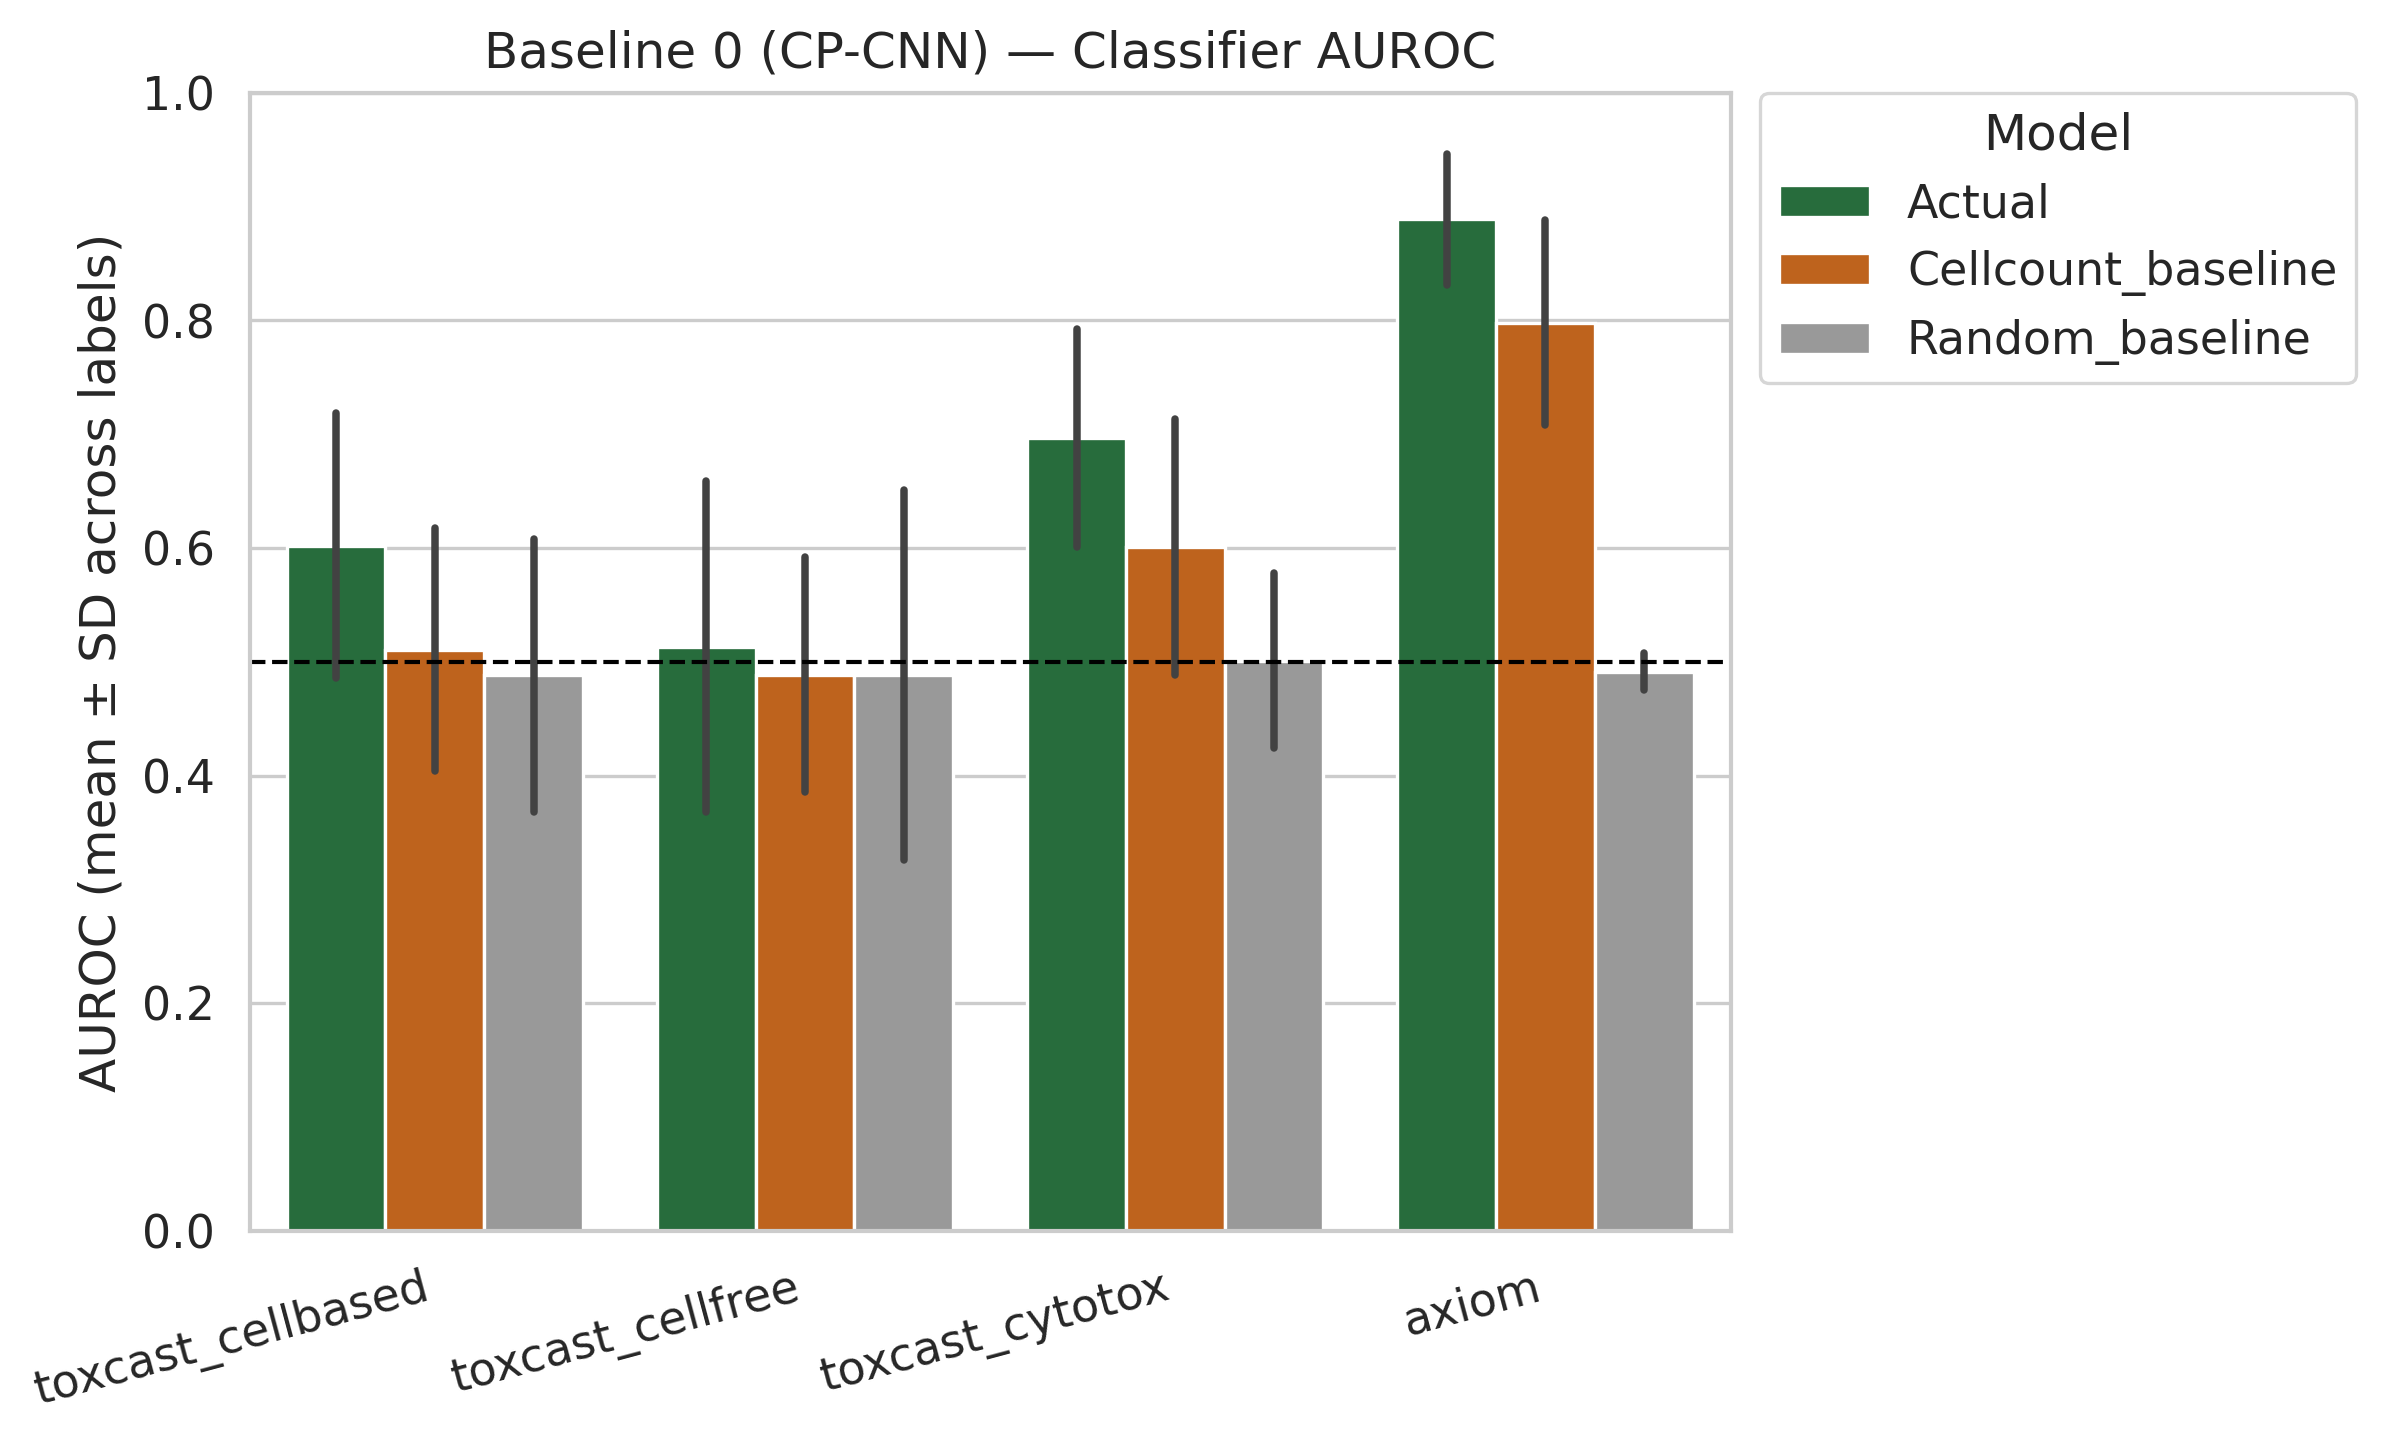

In [17]:
p = eu.plot_classifier_auroc_summary(
    classifier_metrics, FIG / "classifier_auroc_summary",
    "Baseline 0 (CP-CNN) — Classifier AUROC",
)
eu.show(p)


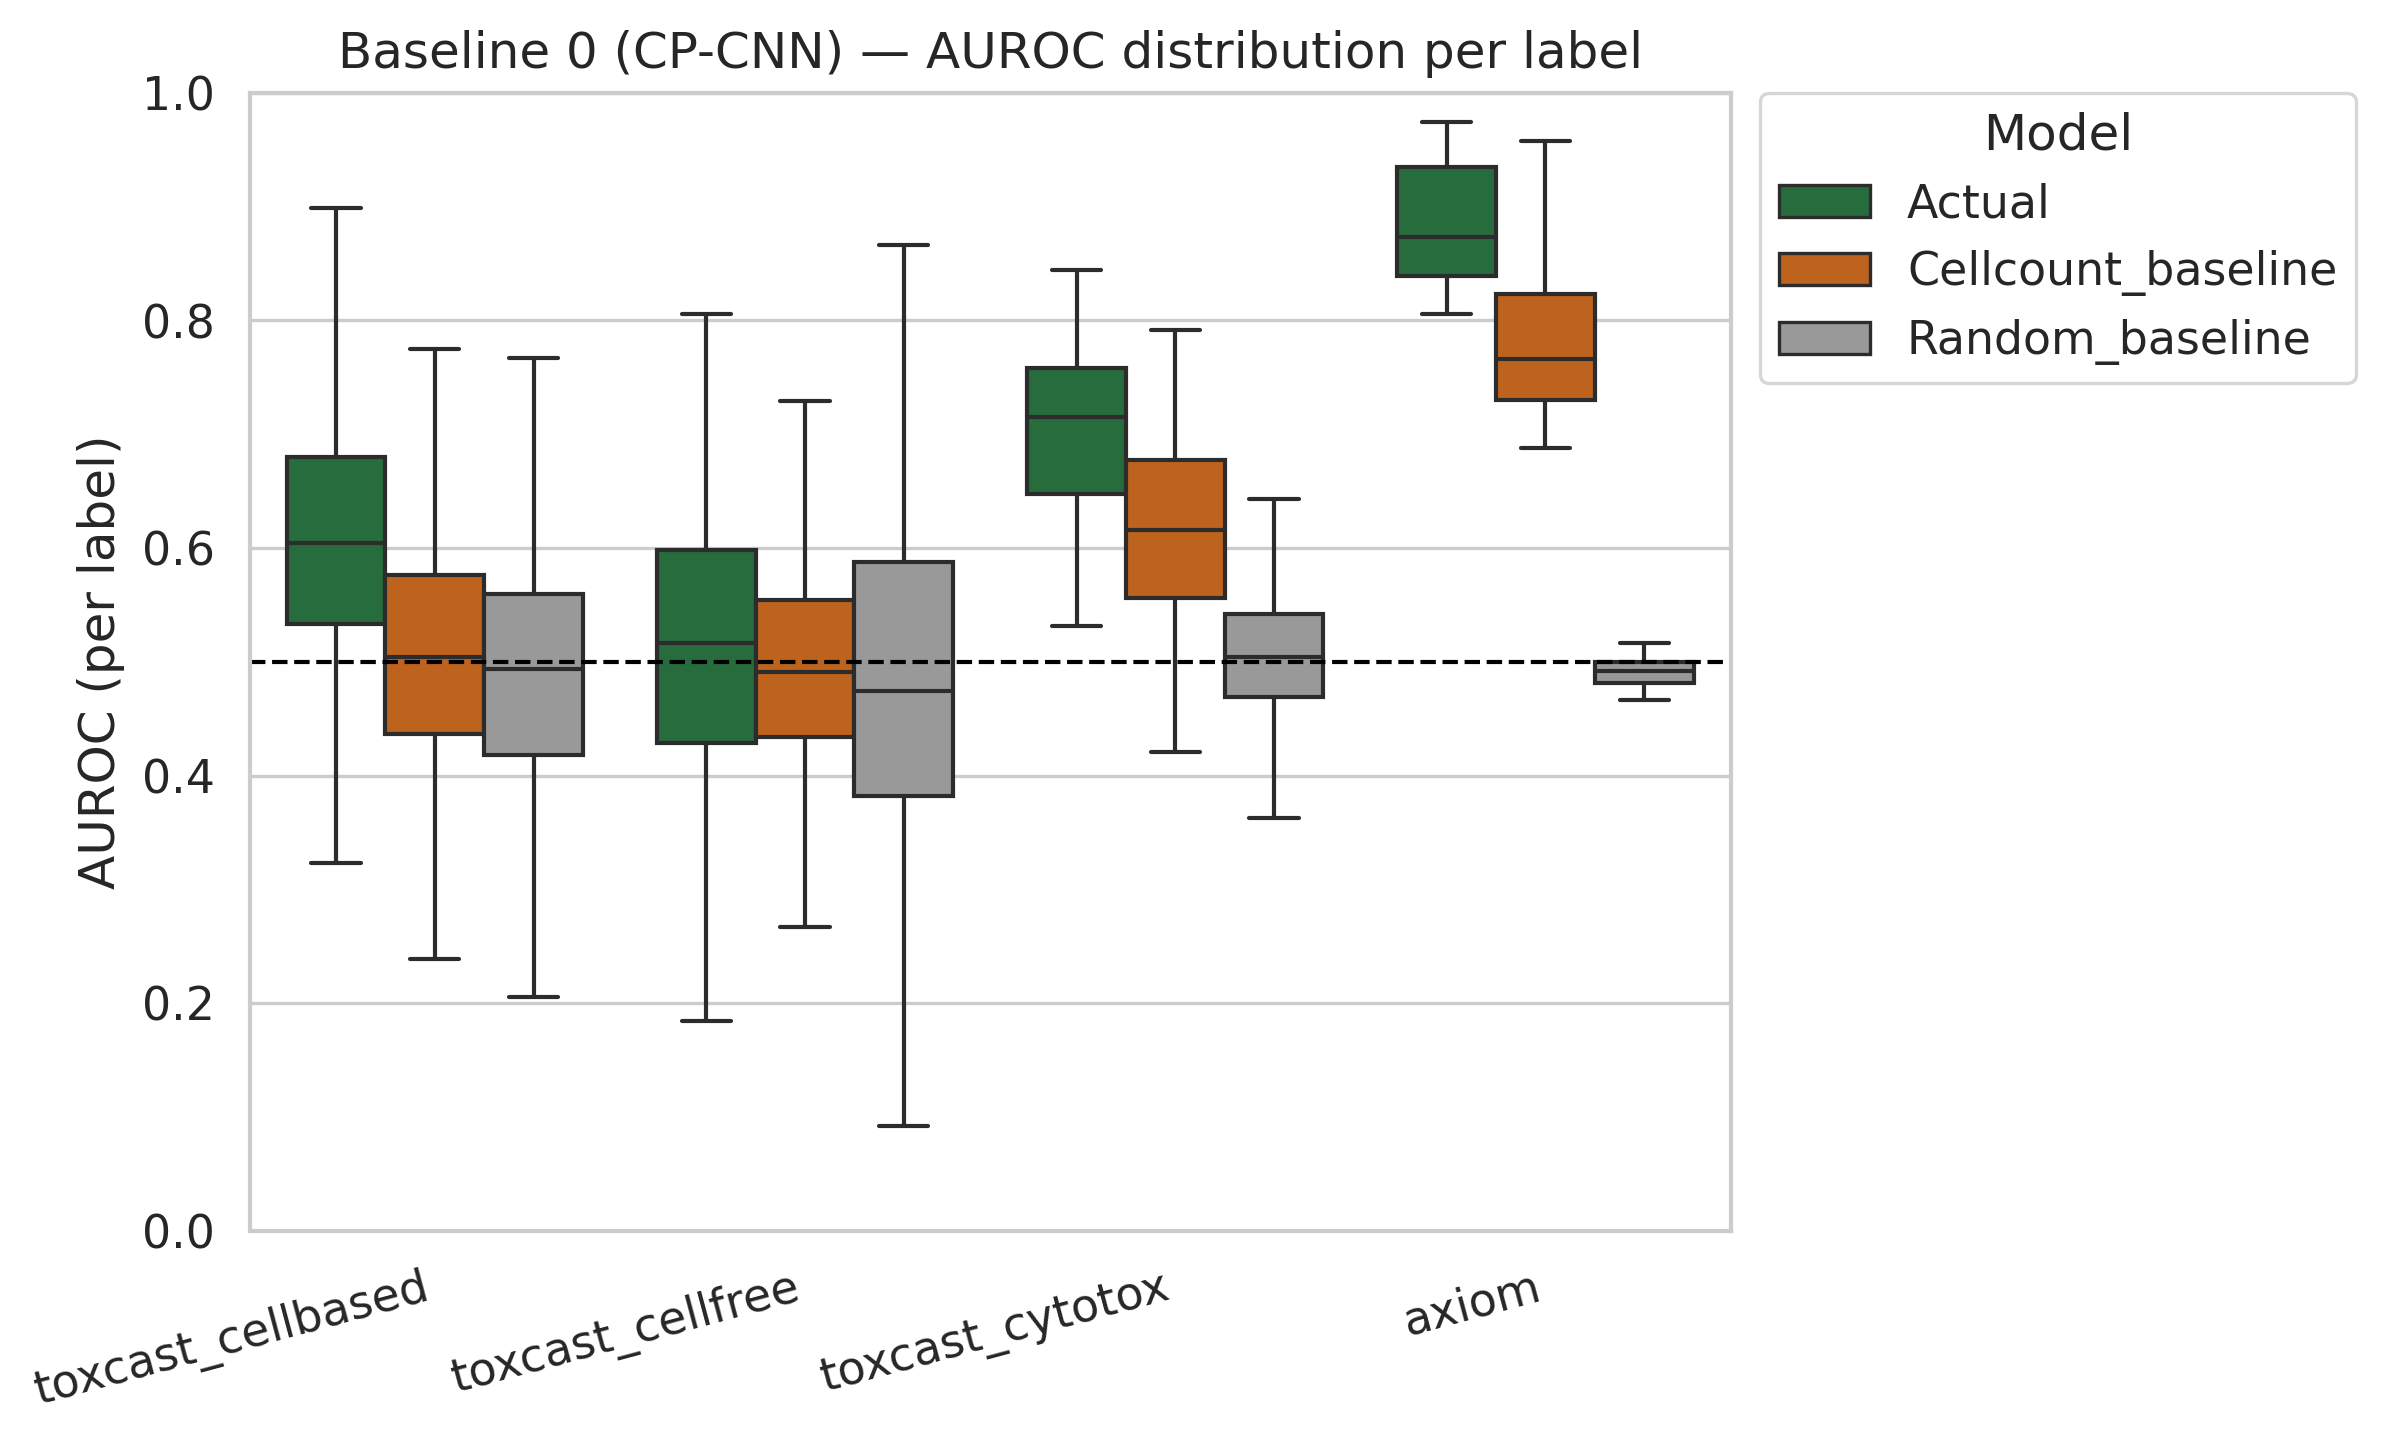

In [18]:
p = eu.plot_classifier_auroc_distribution(
    classifier_metrics, FIG / "classifier_auroc_distribution",
    "Baseline 0 (CP-CNN) — AUROC distribution per label",
)
eu.show(p)


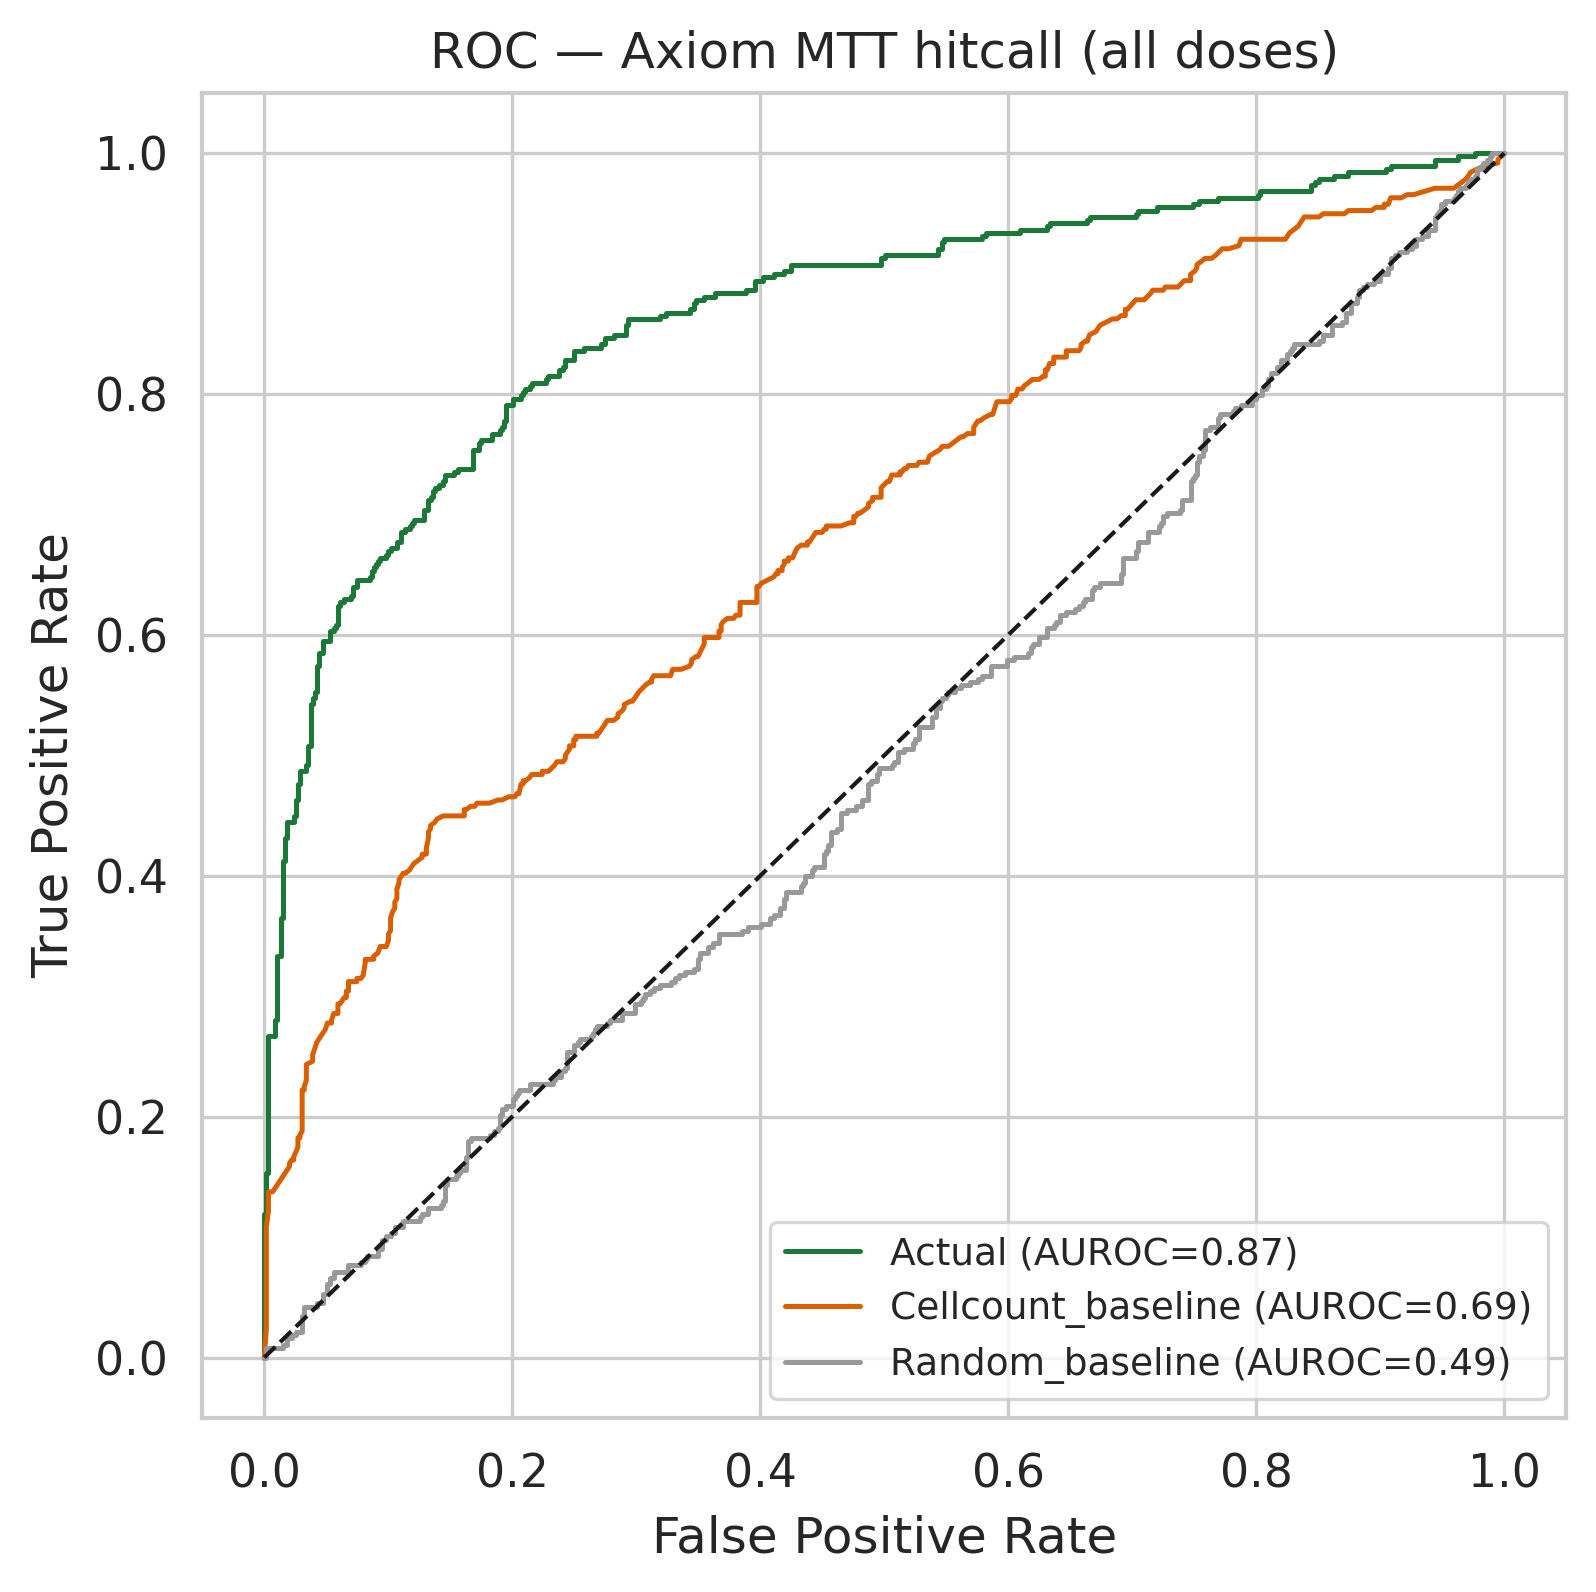

In [19]:
binary_pred = pl.read_parquet(binary_pred_paths["axiom"])
p = eu.plot_roc_curve(binary_pred, "MTT", "all", FIG / "roc_axiom_mtt", "ROC — Axiom MTT hitcall (all doses)")
eu.show(p)


### Regression performance — MTT / LDH

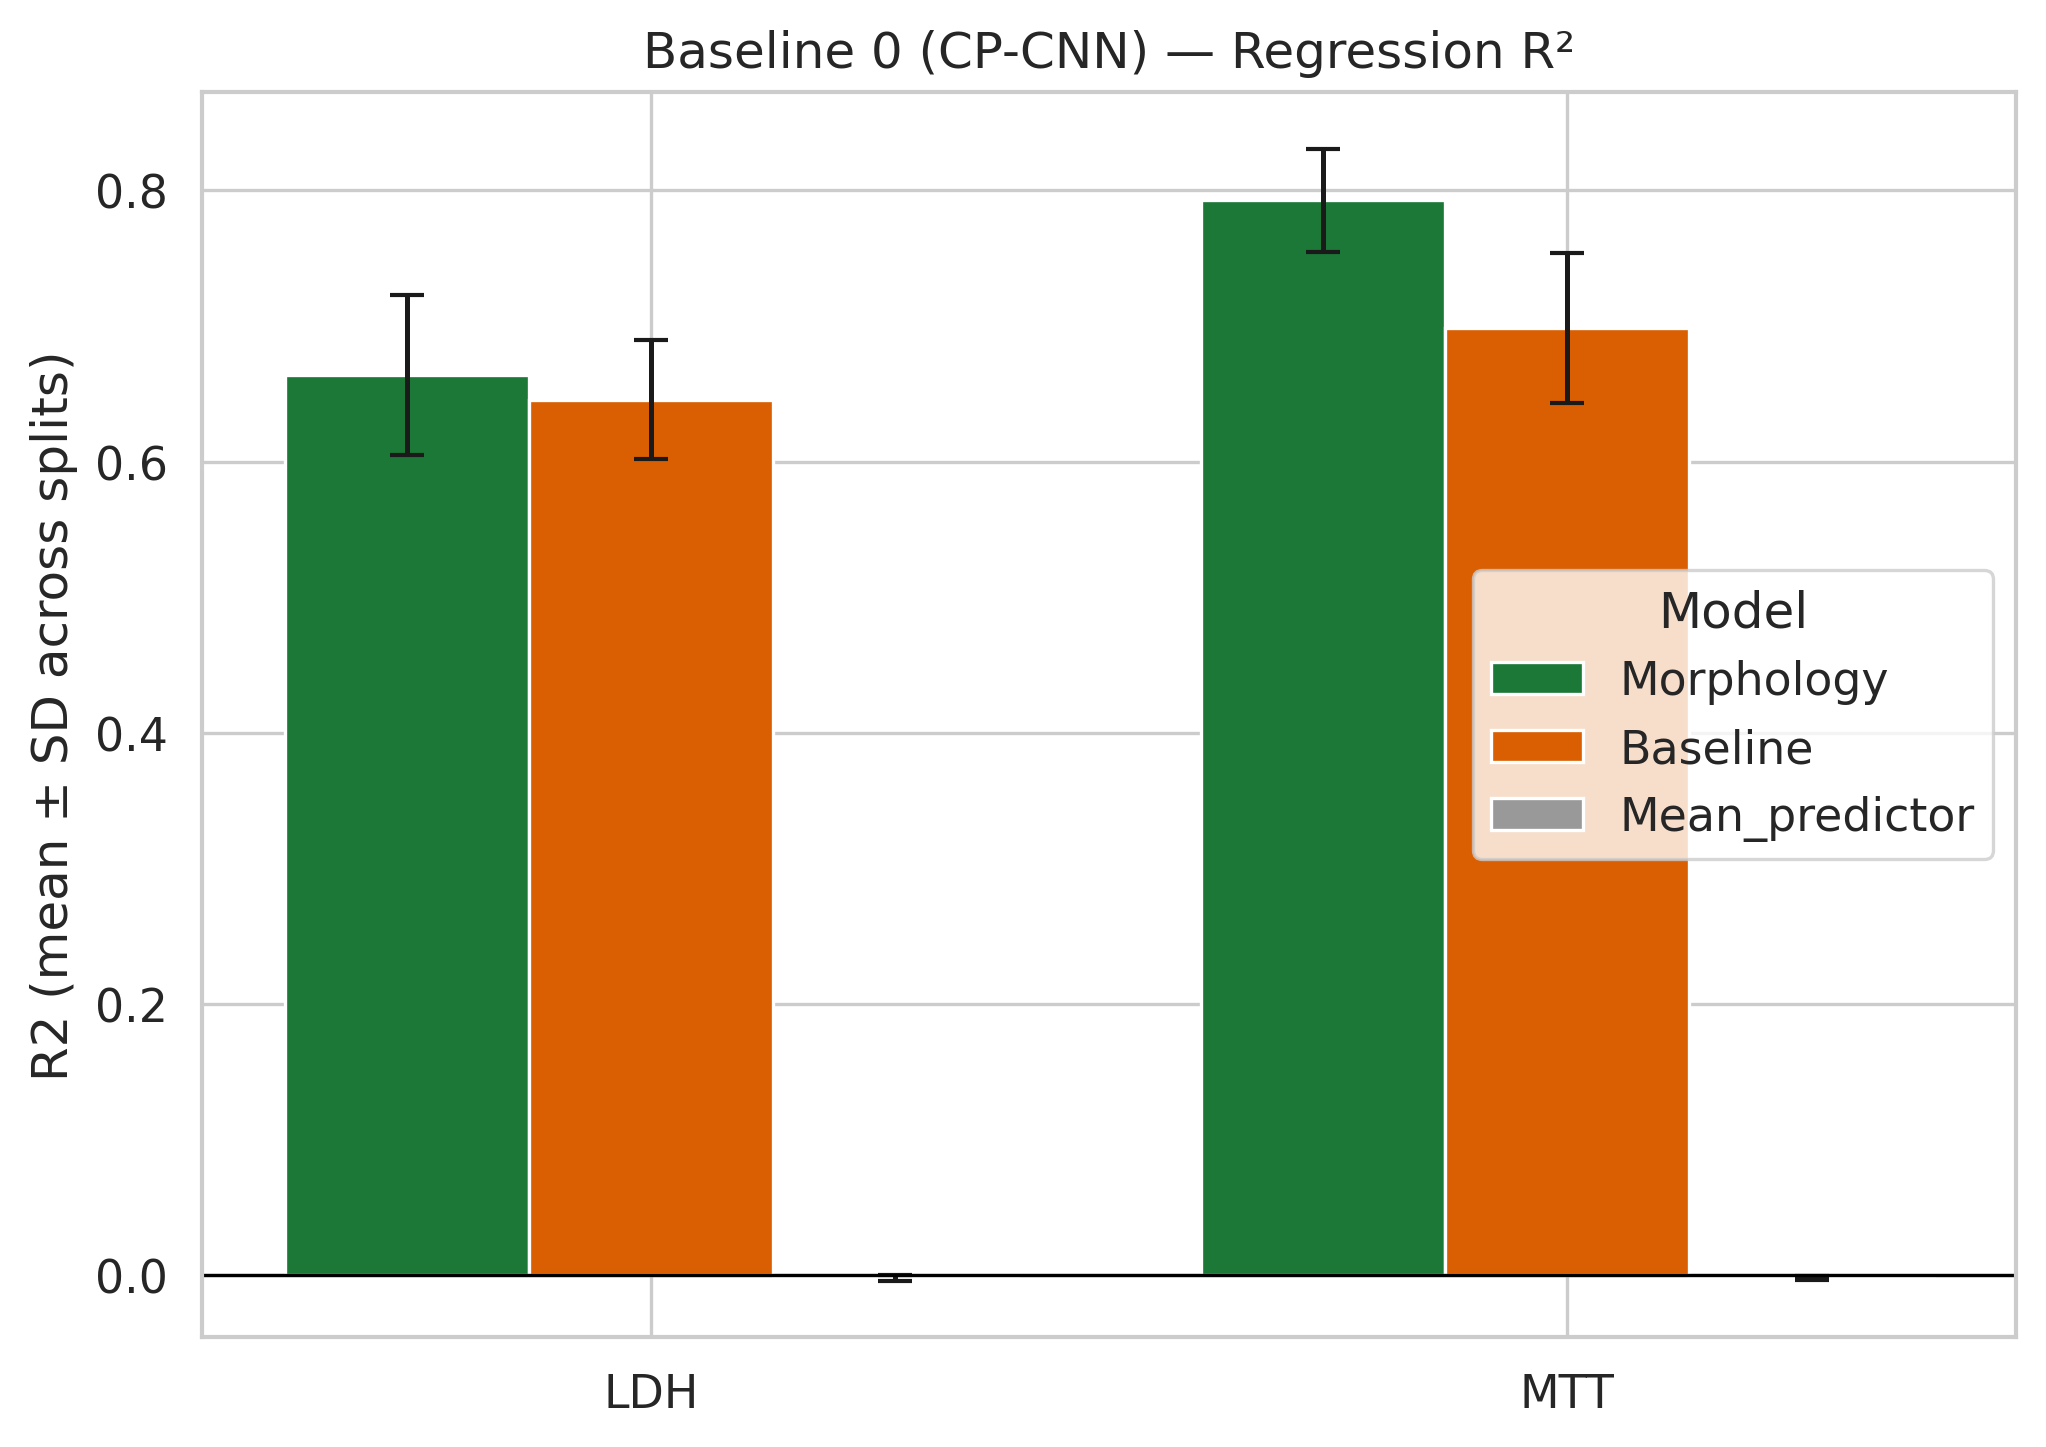

In [20]:
p = eu.plot_regression_metric(regression_summary, "R2", FIG / "regression_r2", "Baseline 0 (CP-CNN) — Regression R²")
eu.show(p)


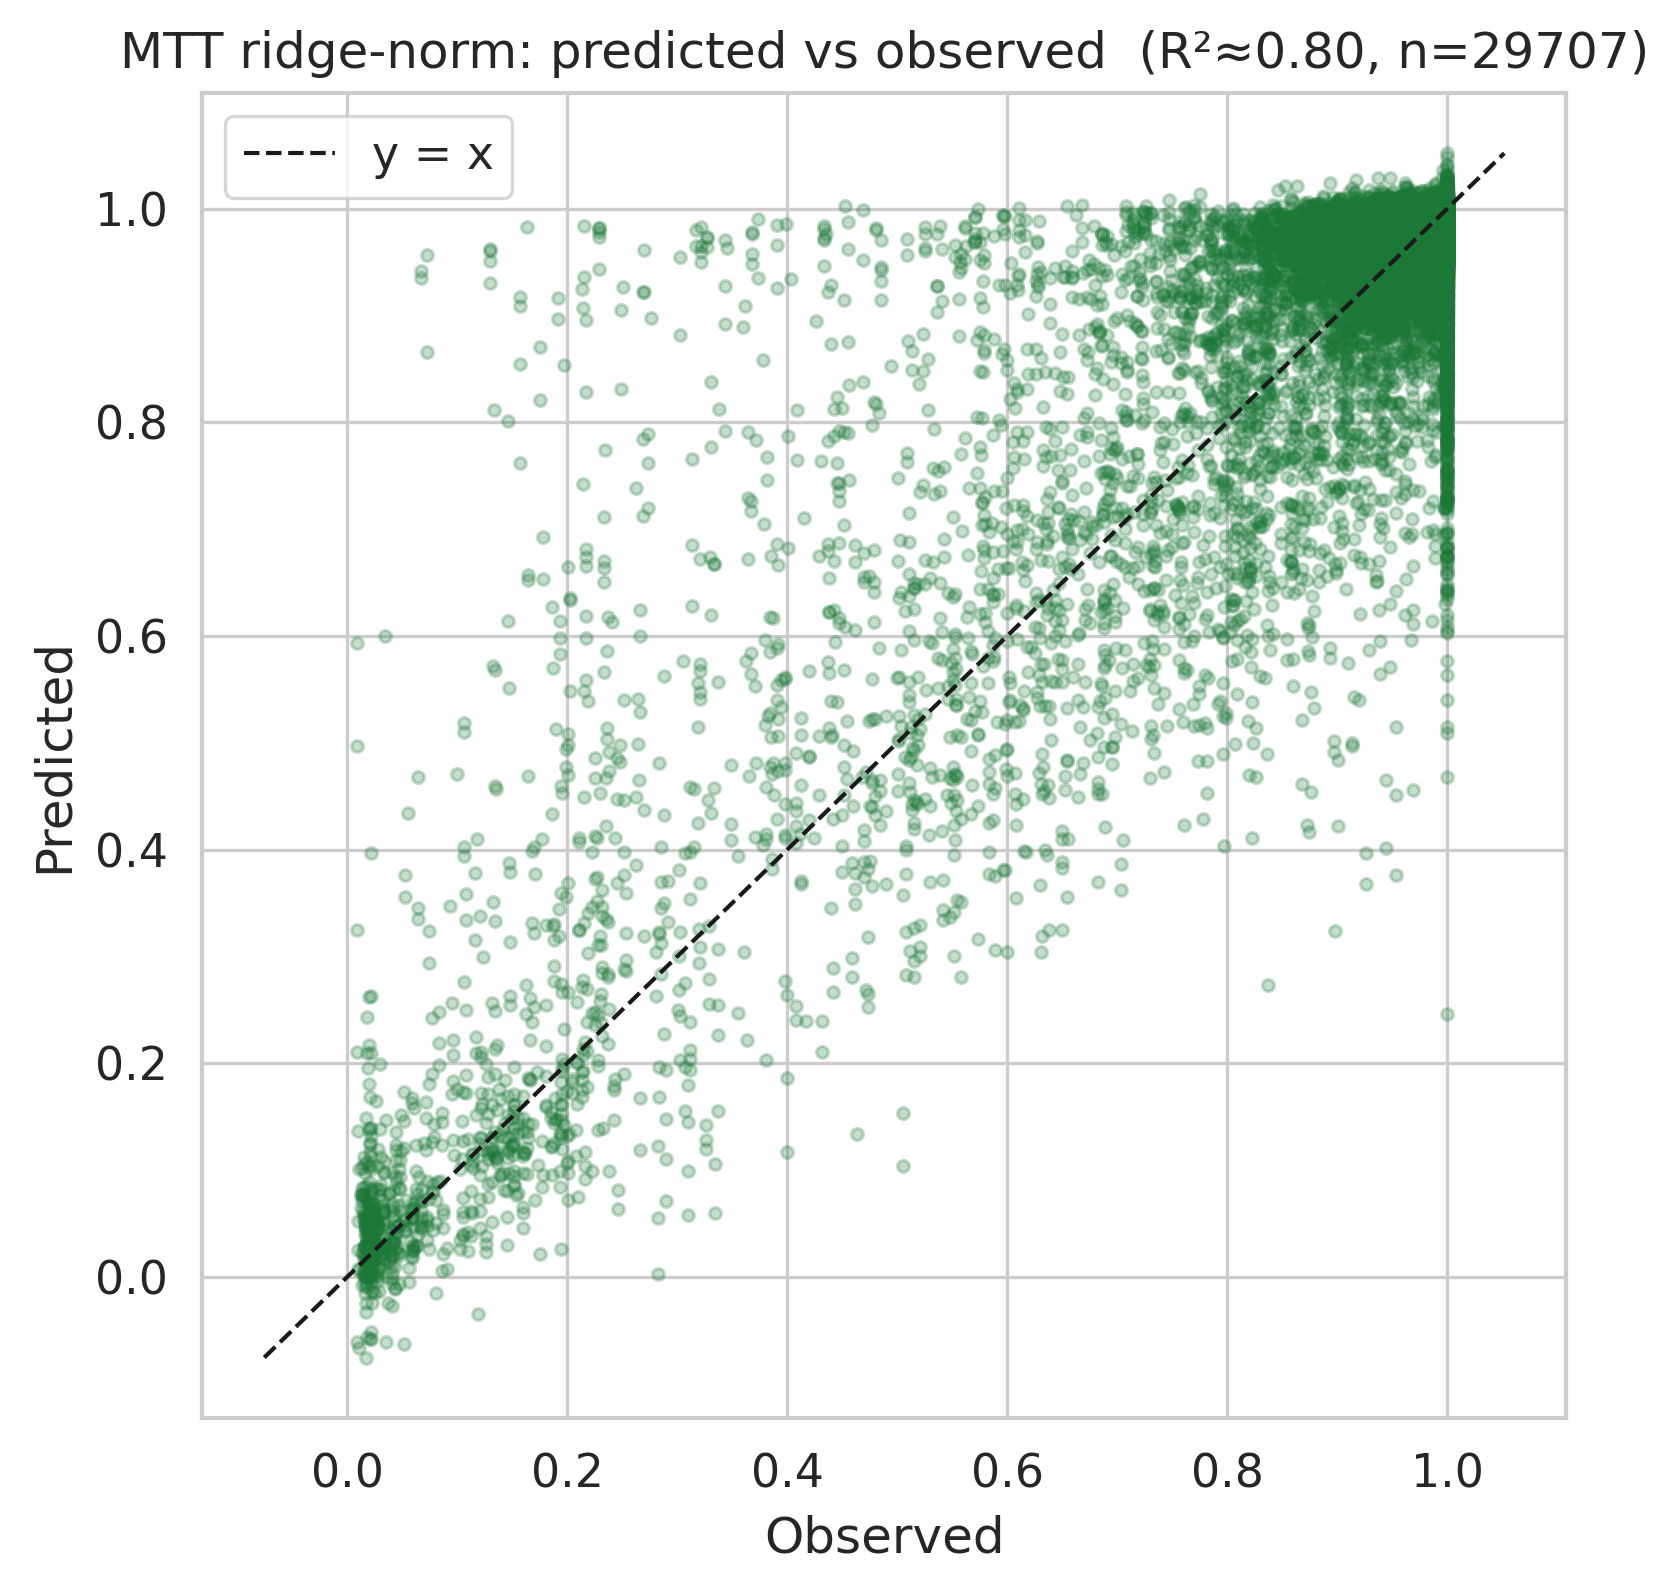

In [21]:
reg_pred = pl.read_parquet(axiom_cont_pred_path)
p = eu.plot_pred_vs_obs(reg_pred, "Metadata_mtt_ridge_norm", "Morphology", FIG / "pred_vs_obs_mtt", "MTT ridge-norm: predicted vs observed")
eu.show(p)


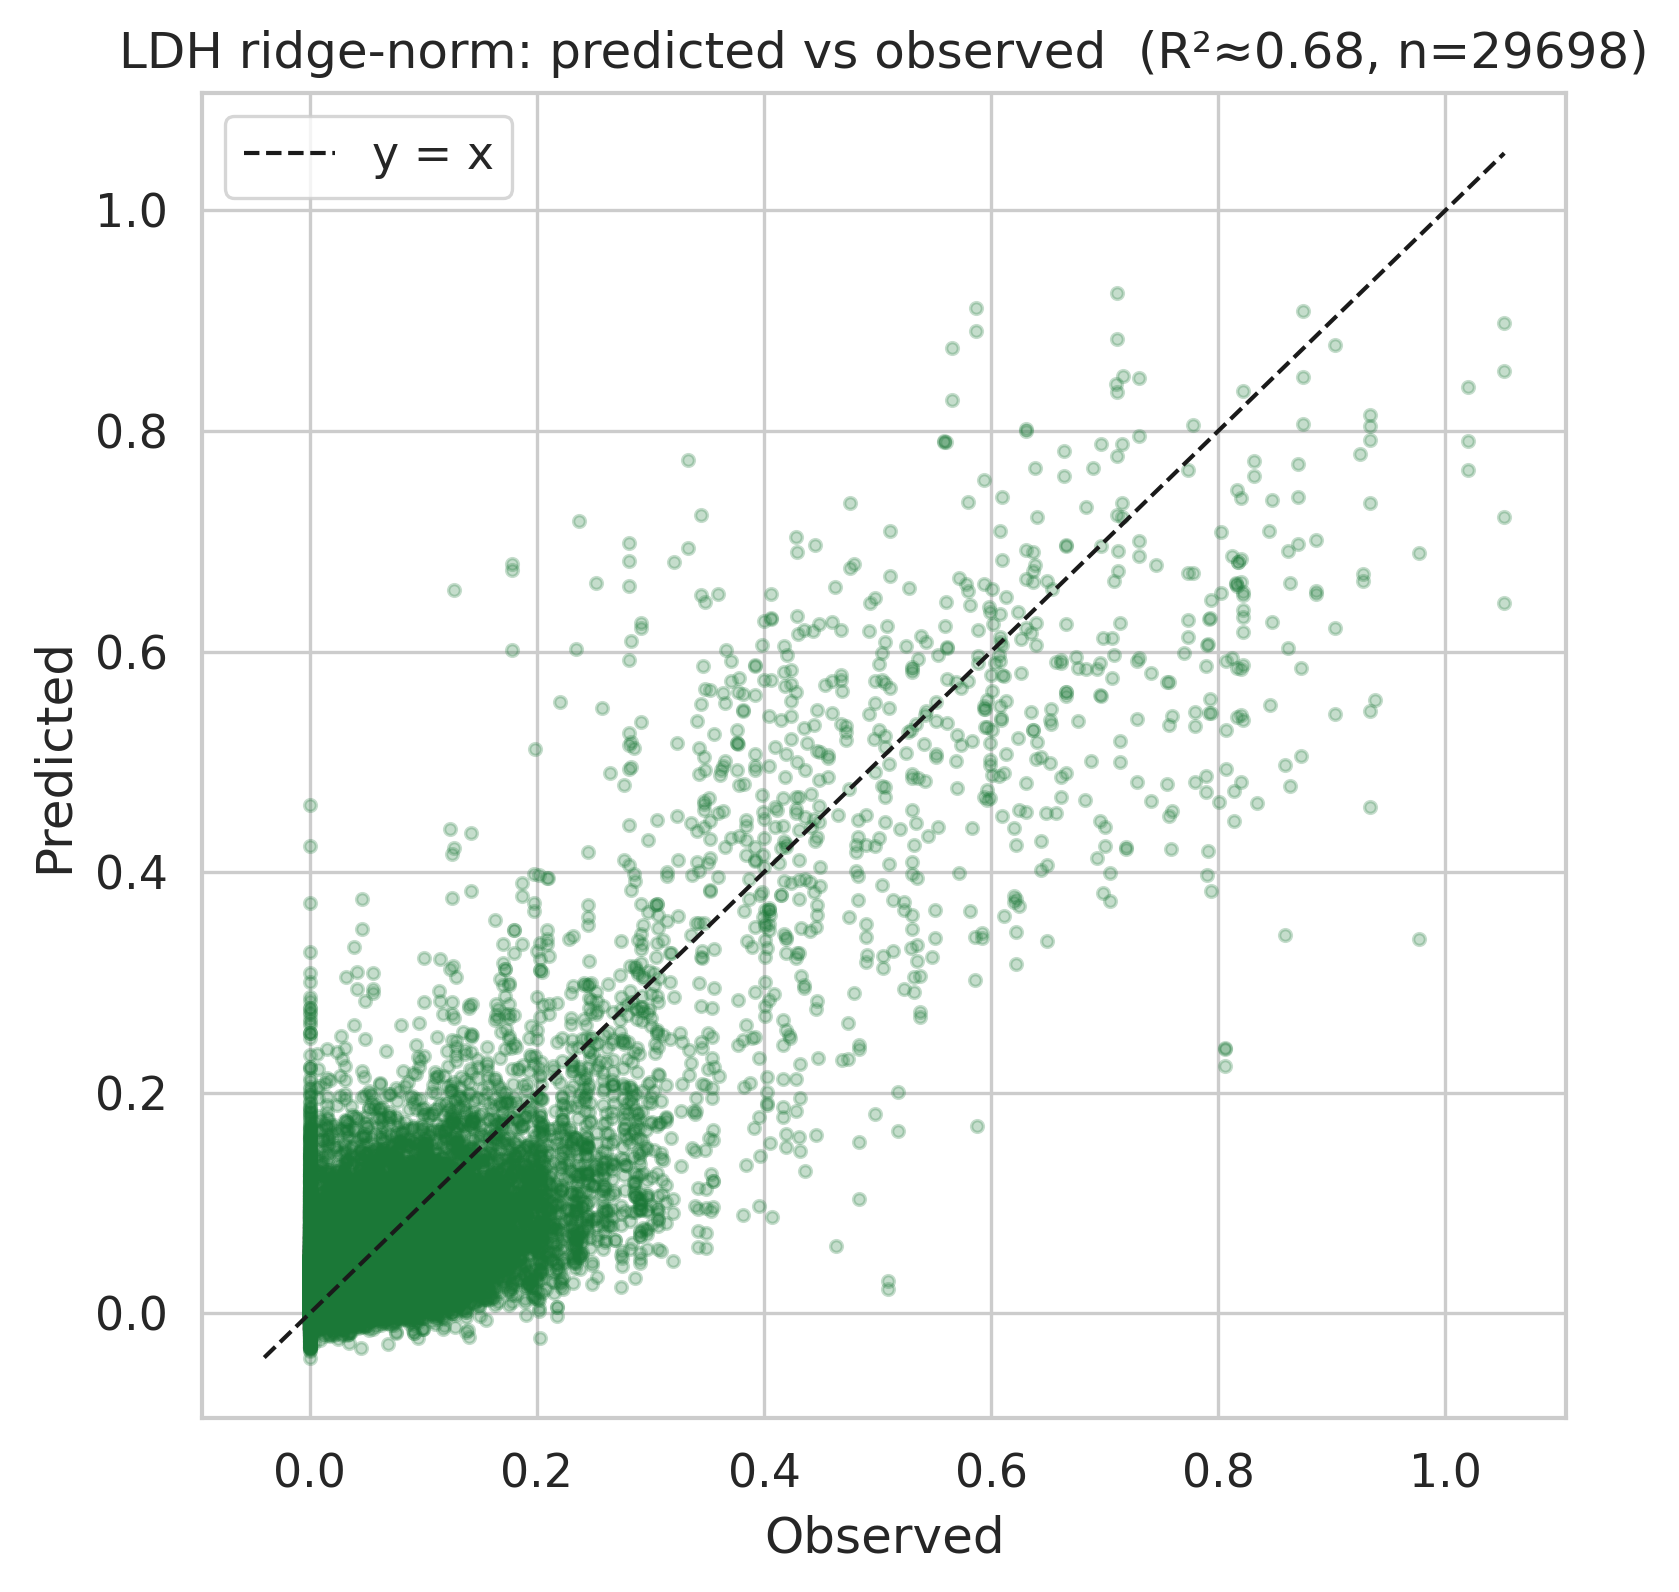

In [22]:
p = eu.plot_pred_vs_obs(reg_pred, "Metadata_ldh_ridge_norm", "Morphology", FIG / "pred_vs_obs_ldh", "LDH ridge-norm: predicted vs observed")
eu.show(p)


### Points of departure (POD)

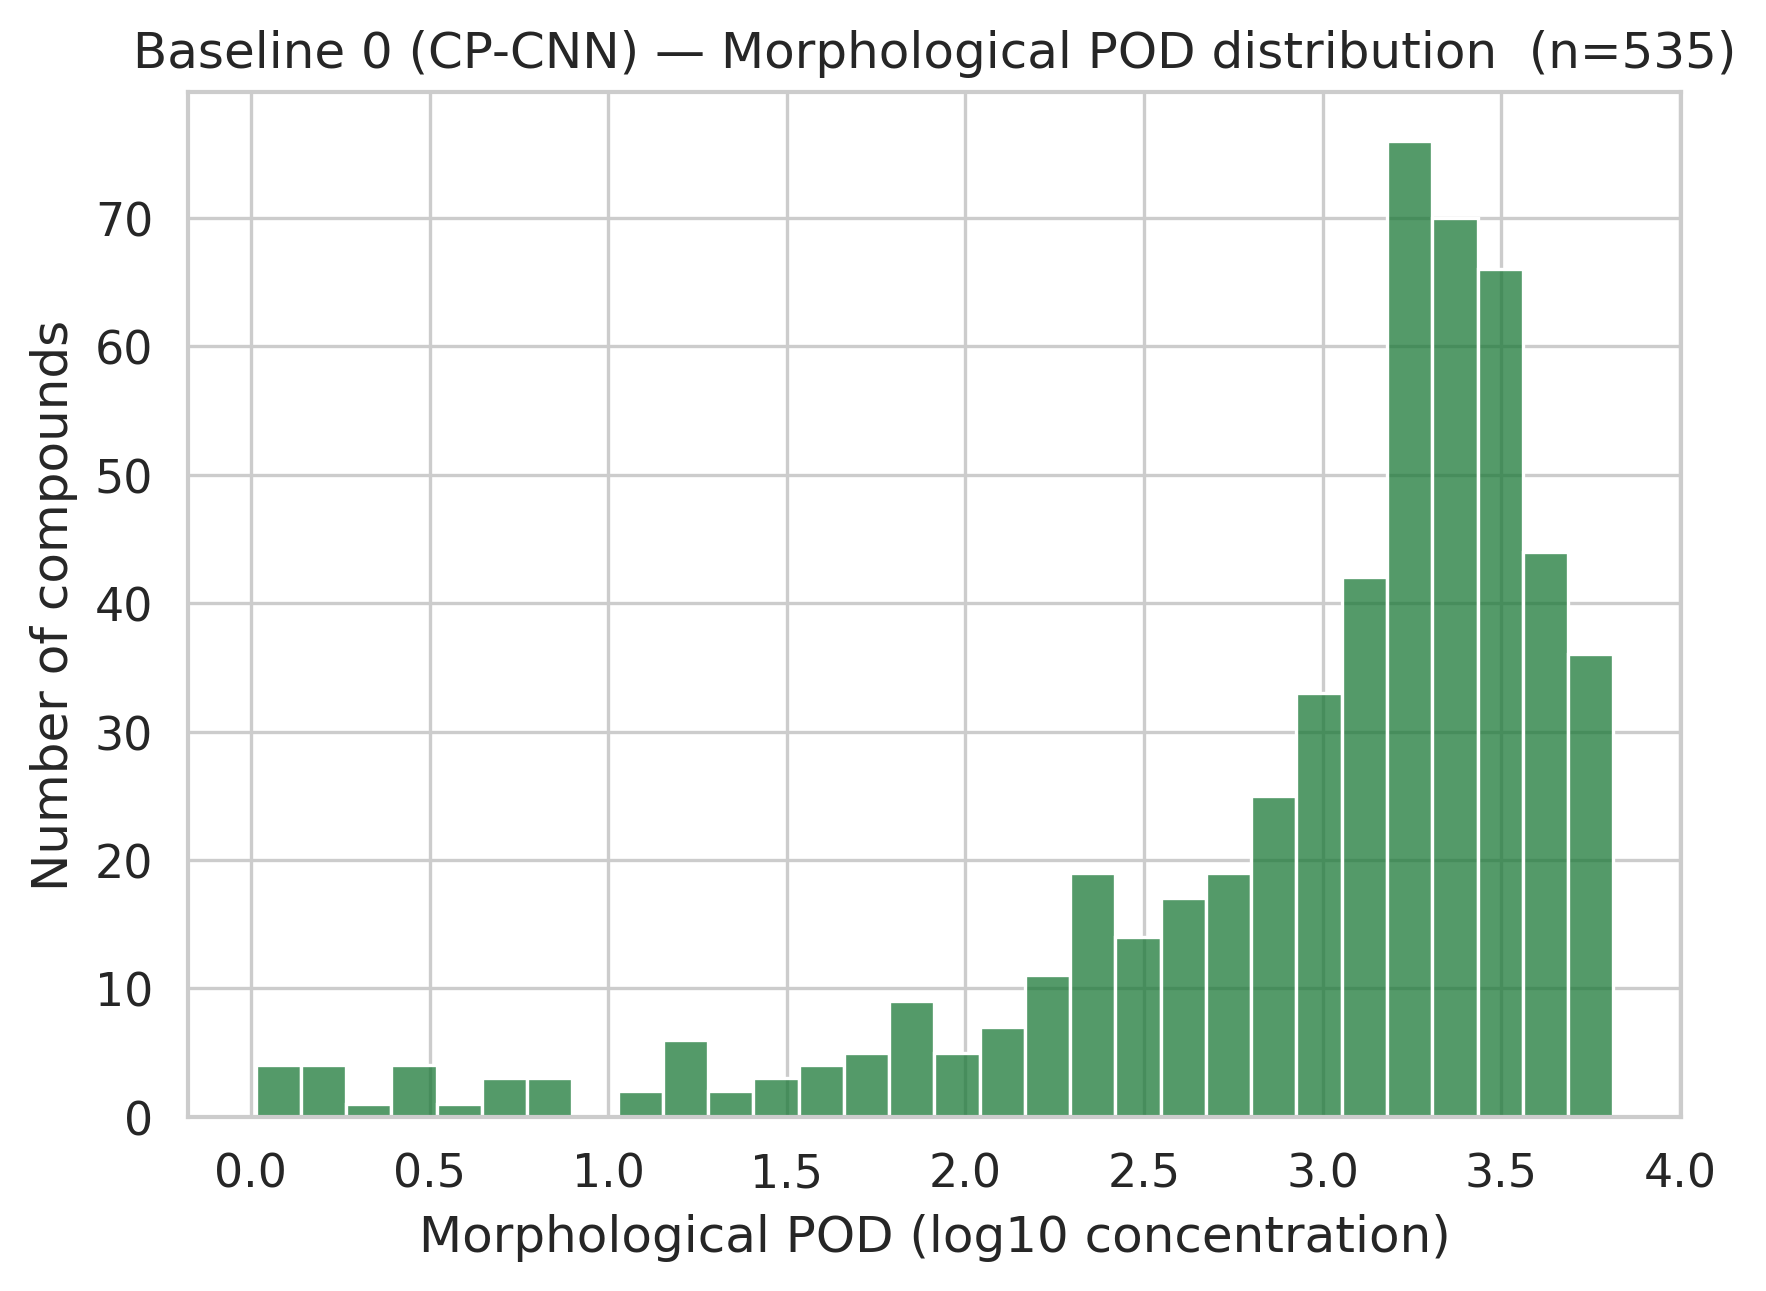

In [23]:
p = eu.plot_pod_distribution(pods, FIG / "pod_distribution", "Baseline 0 (CP-CNN) — Morphological POD distribution")
eu.show(p)


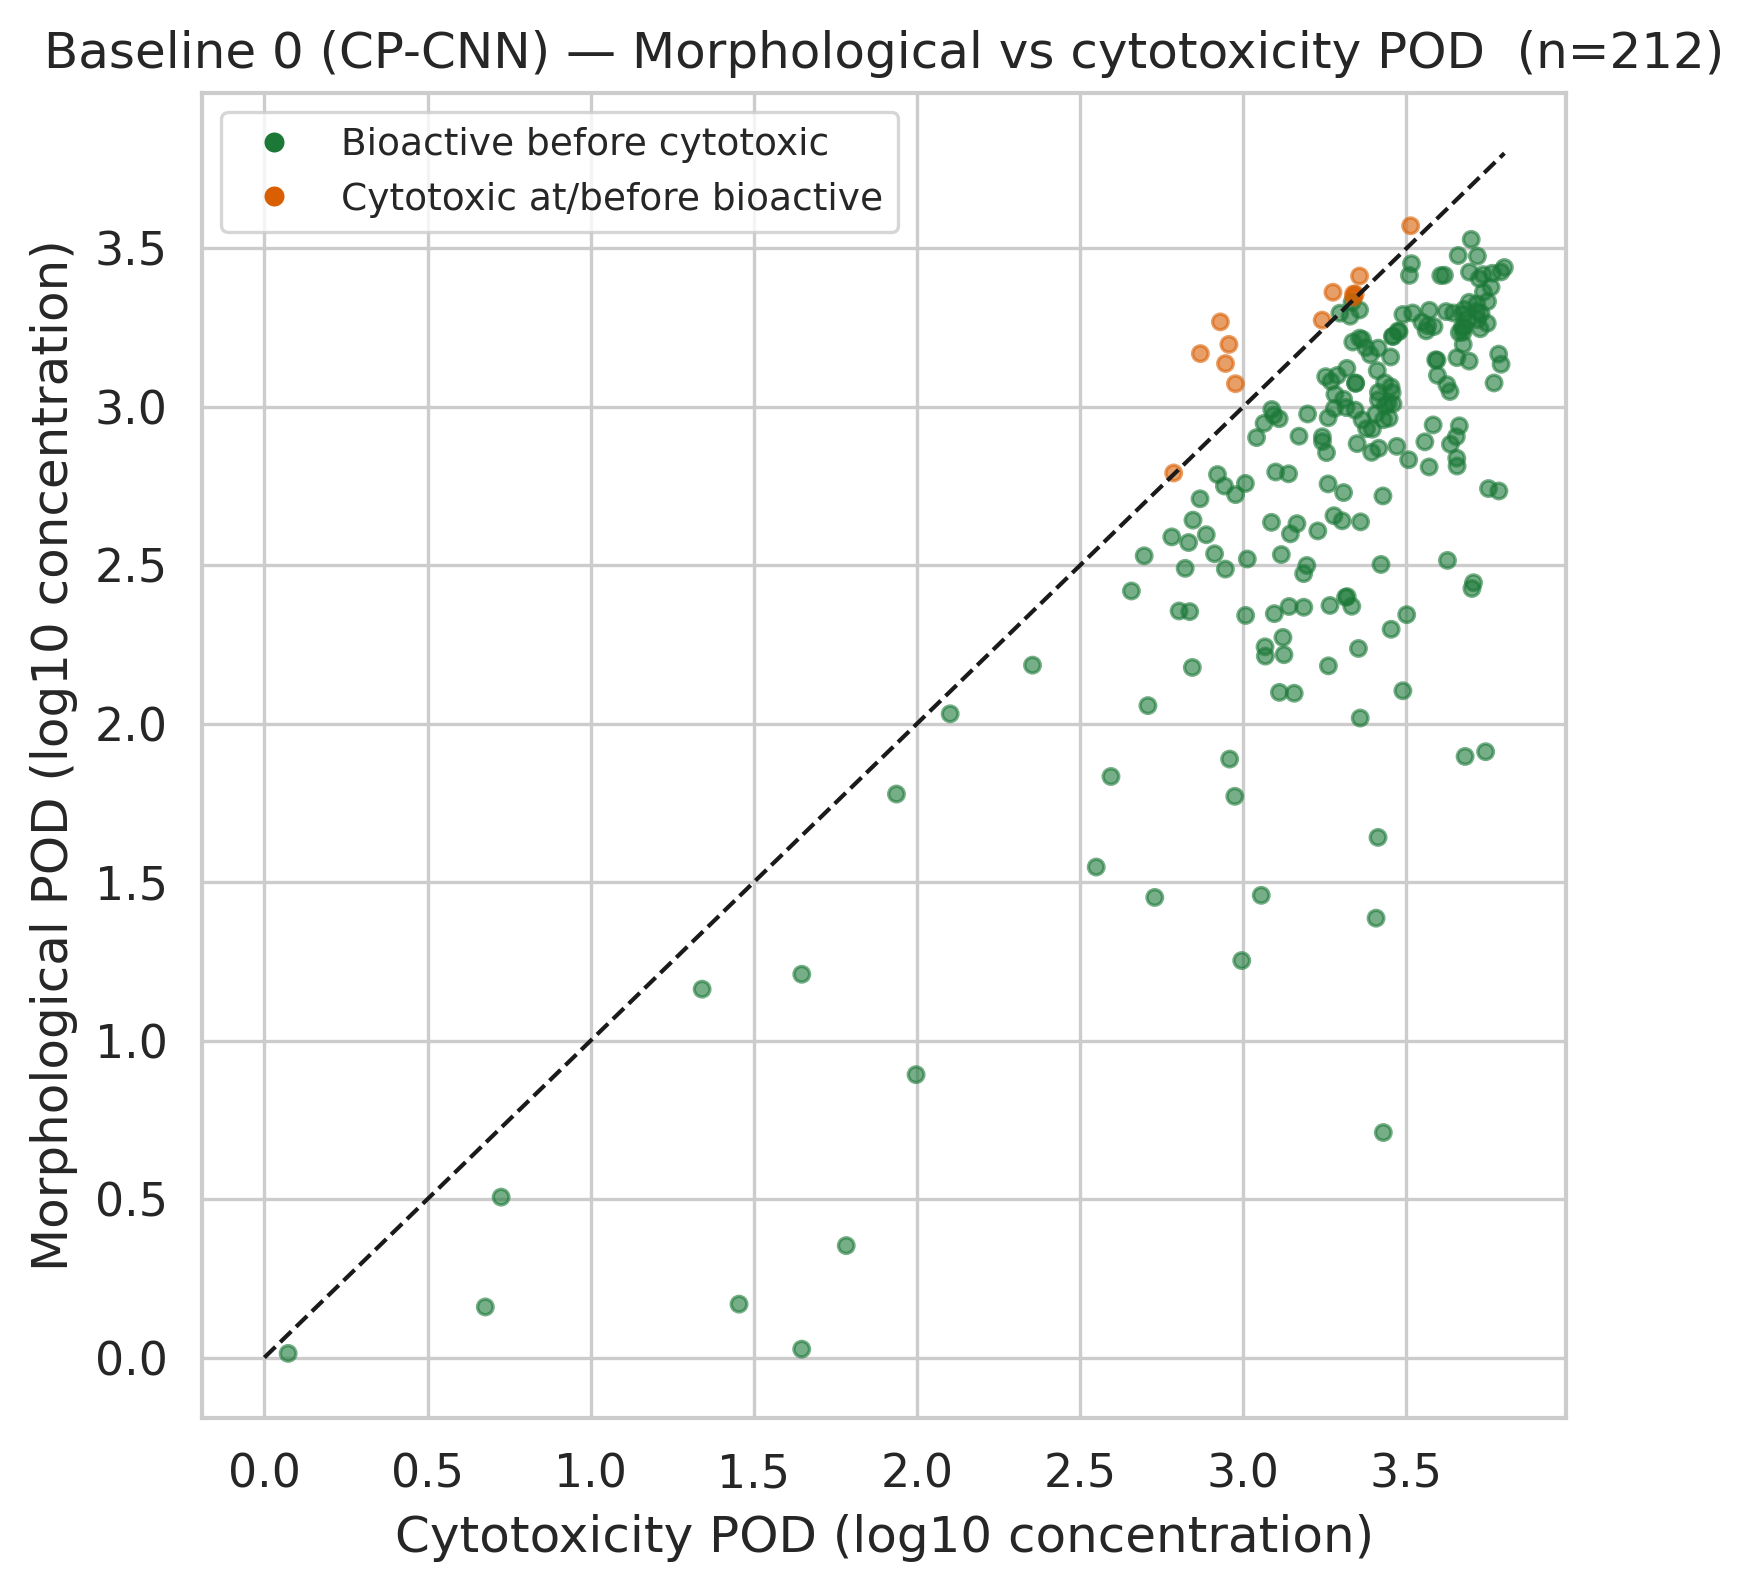

In [24]:
p = eu.plot_pod_vs_cytotox(pods, FIG / "pod_vs_cytotox", "Baseline 0 (CP-CNN) — Morphological vs cytotoxicity POD")
eu.show(p)


### Cross-experiment comparison

These two are the ones that matter for the dissertation's "improvements" chapter. They currently show only `baseline_0` since no B1/B2/B3 exist yet — once a future notebook writes `3_experiments/outputs/<name>/metrics/<name>_{classifier,regression}_metrics.parquet` in the same schema, just add its name to the `load_*_metrics(...)` calls below and both bars/groups appear automatically.

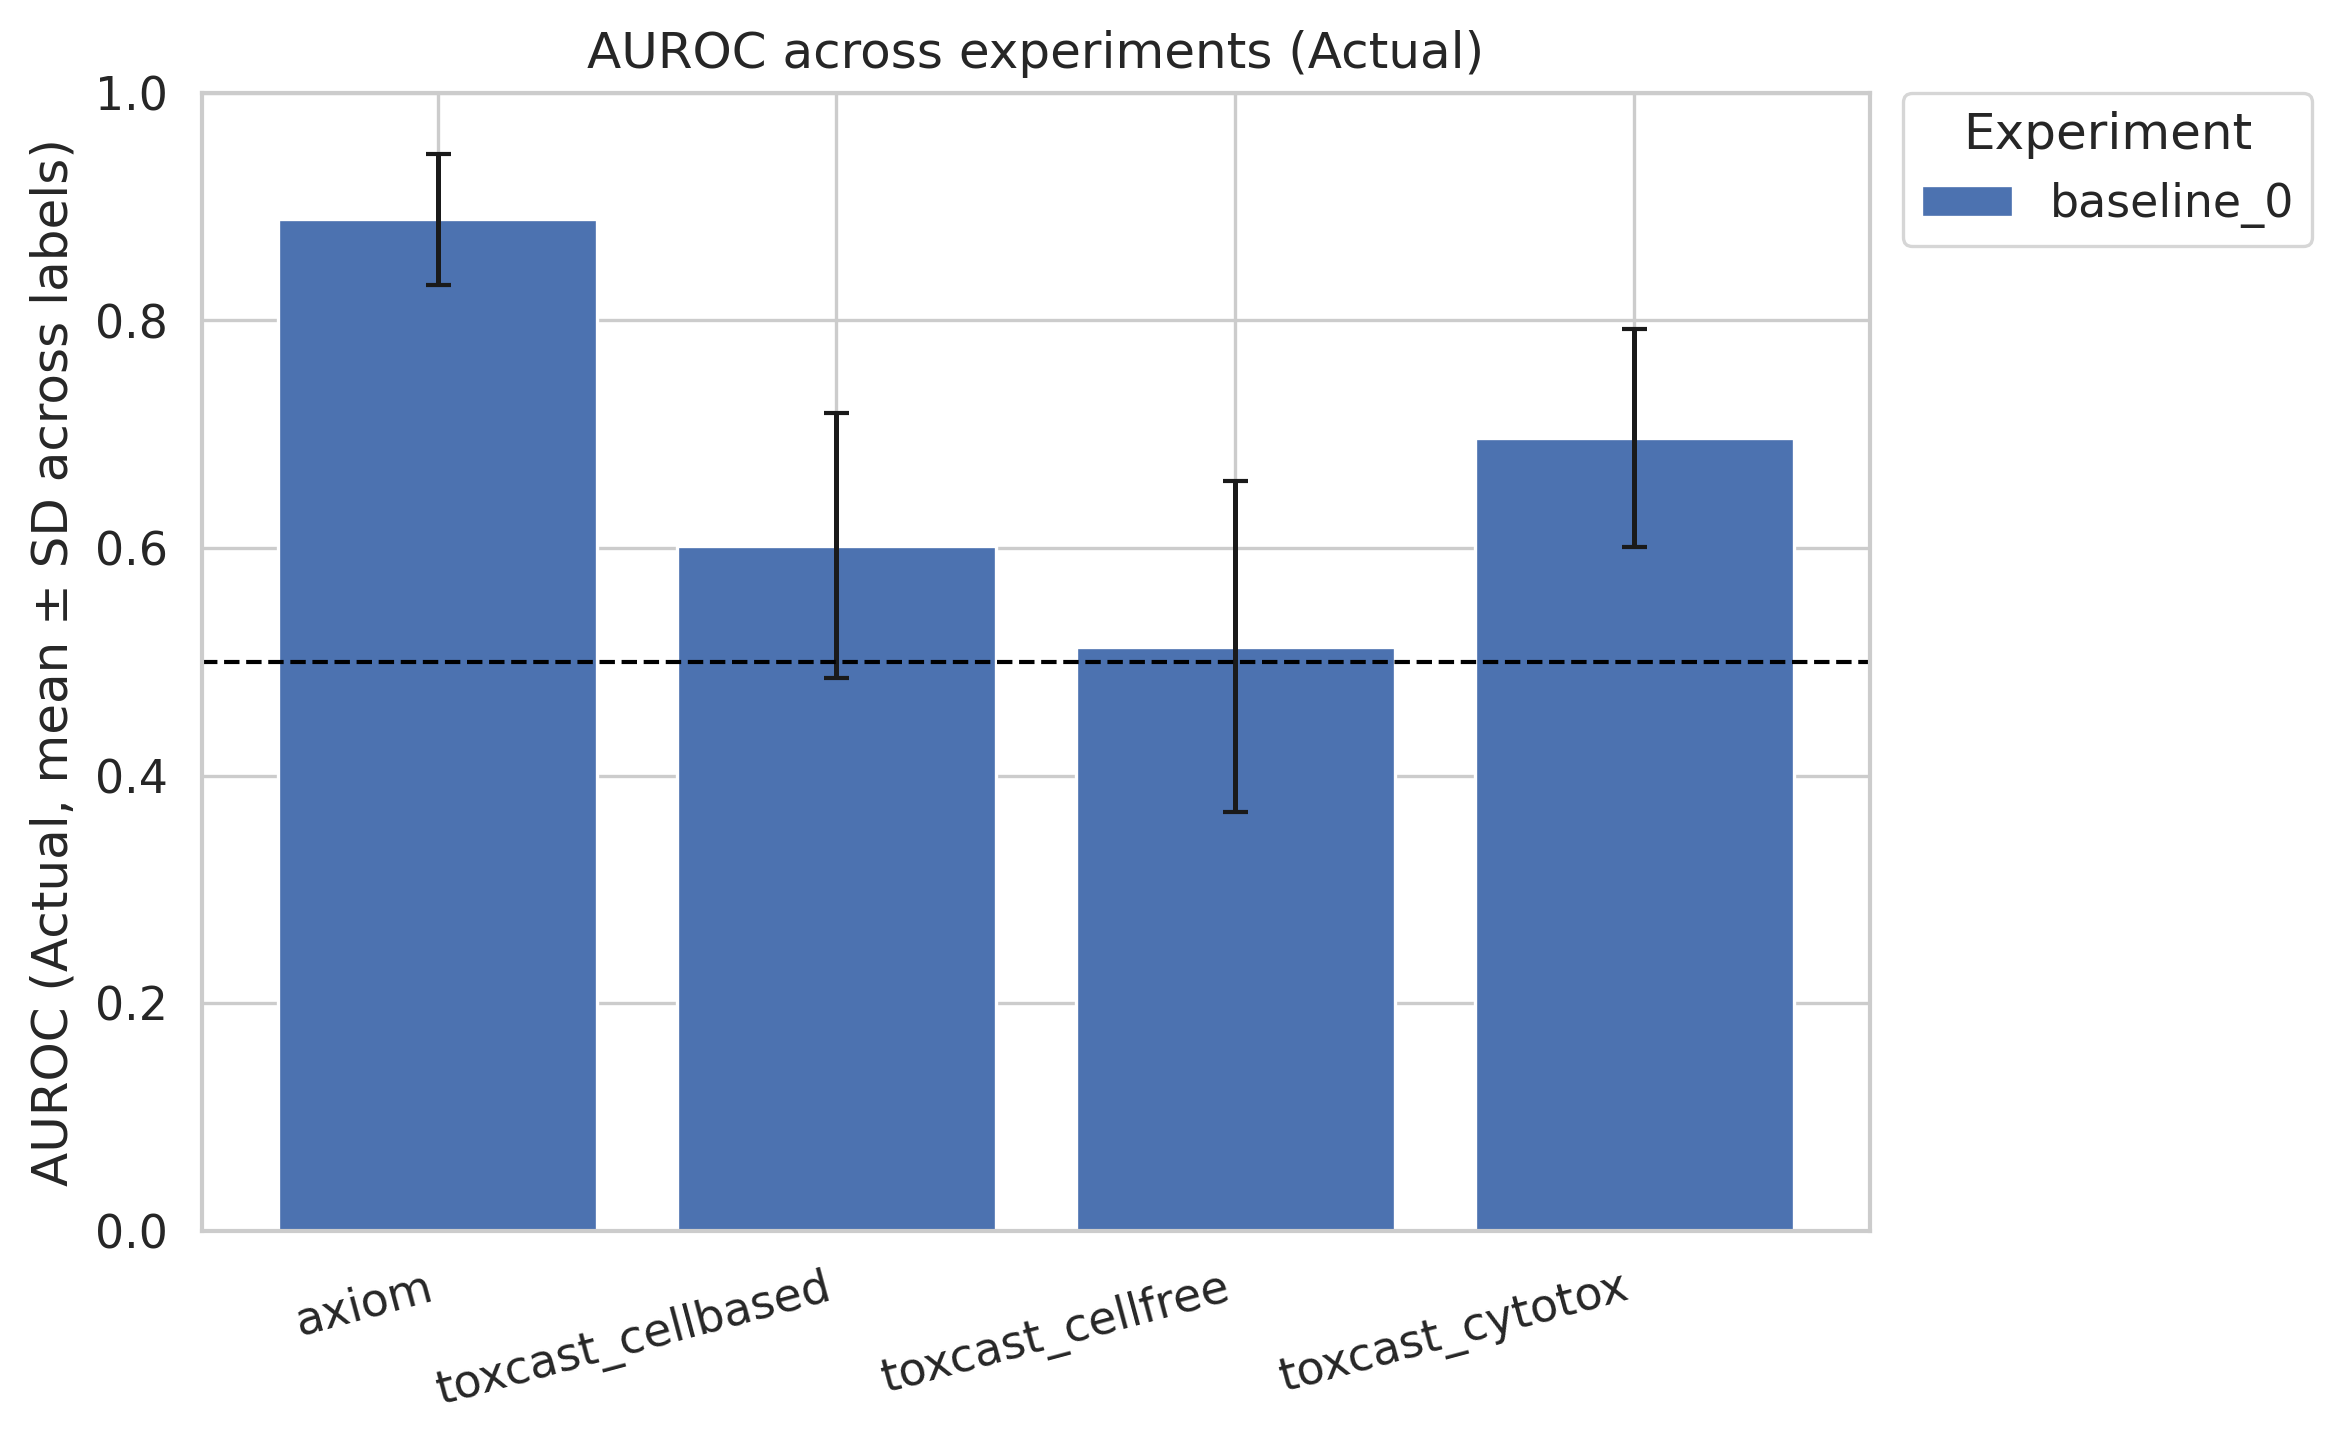

In [25]:
EXPERIMENTS = ["baseline_0"]  # append e.g. "b1_..." here once it exists

cm_multi = eu.load_classifier_metrics(*EXPERIMENTS)
p = eu.plot_experiment_comparison_auroc(cm_multi, FIG / "compare_auroc", "AUROC across experiments (Actual)")
eu.show(p)


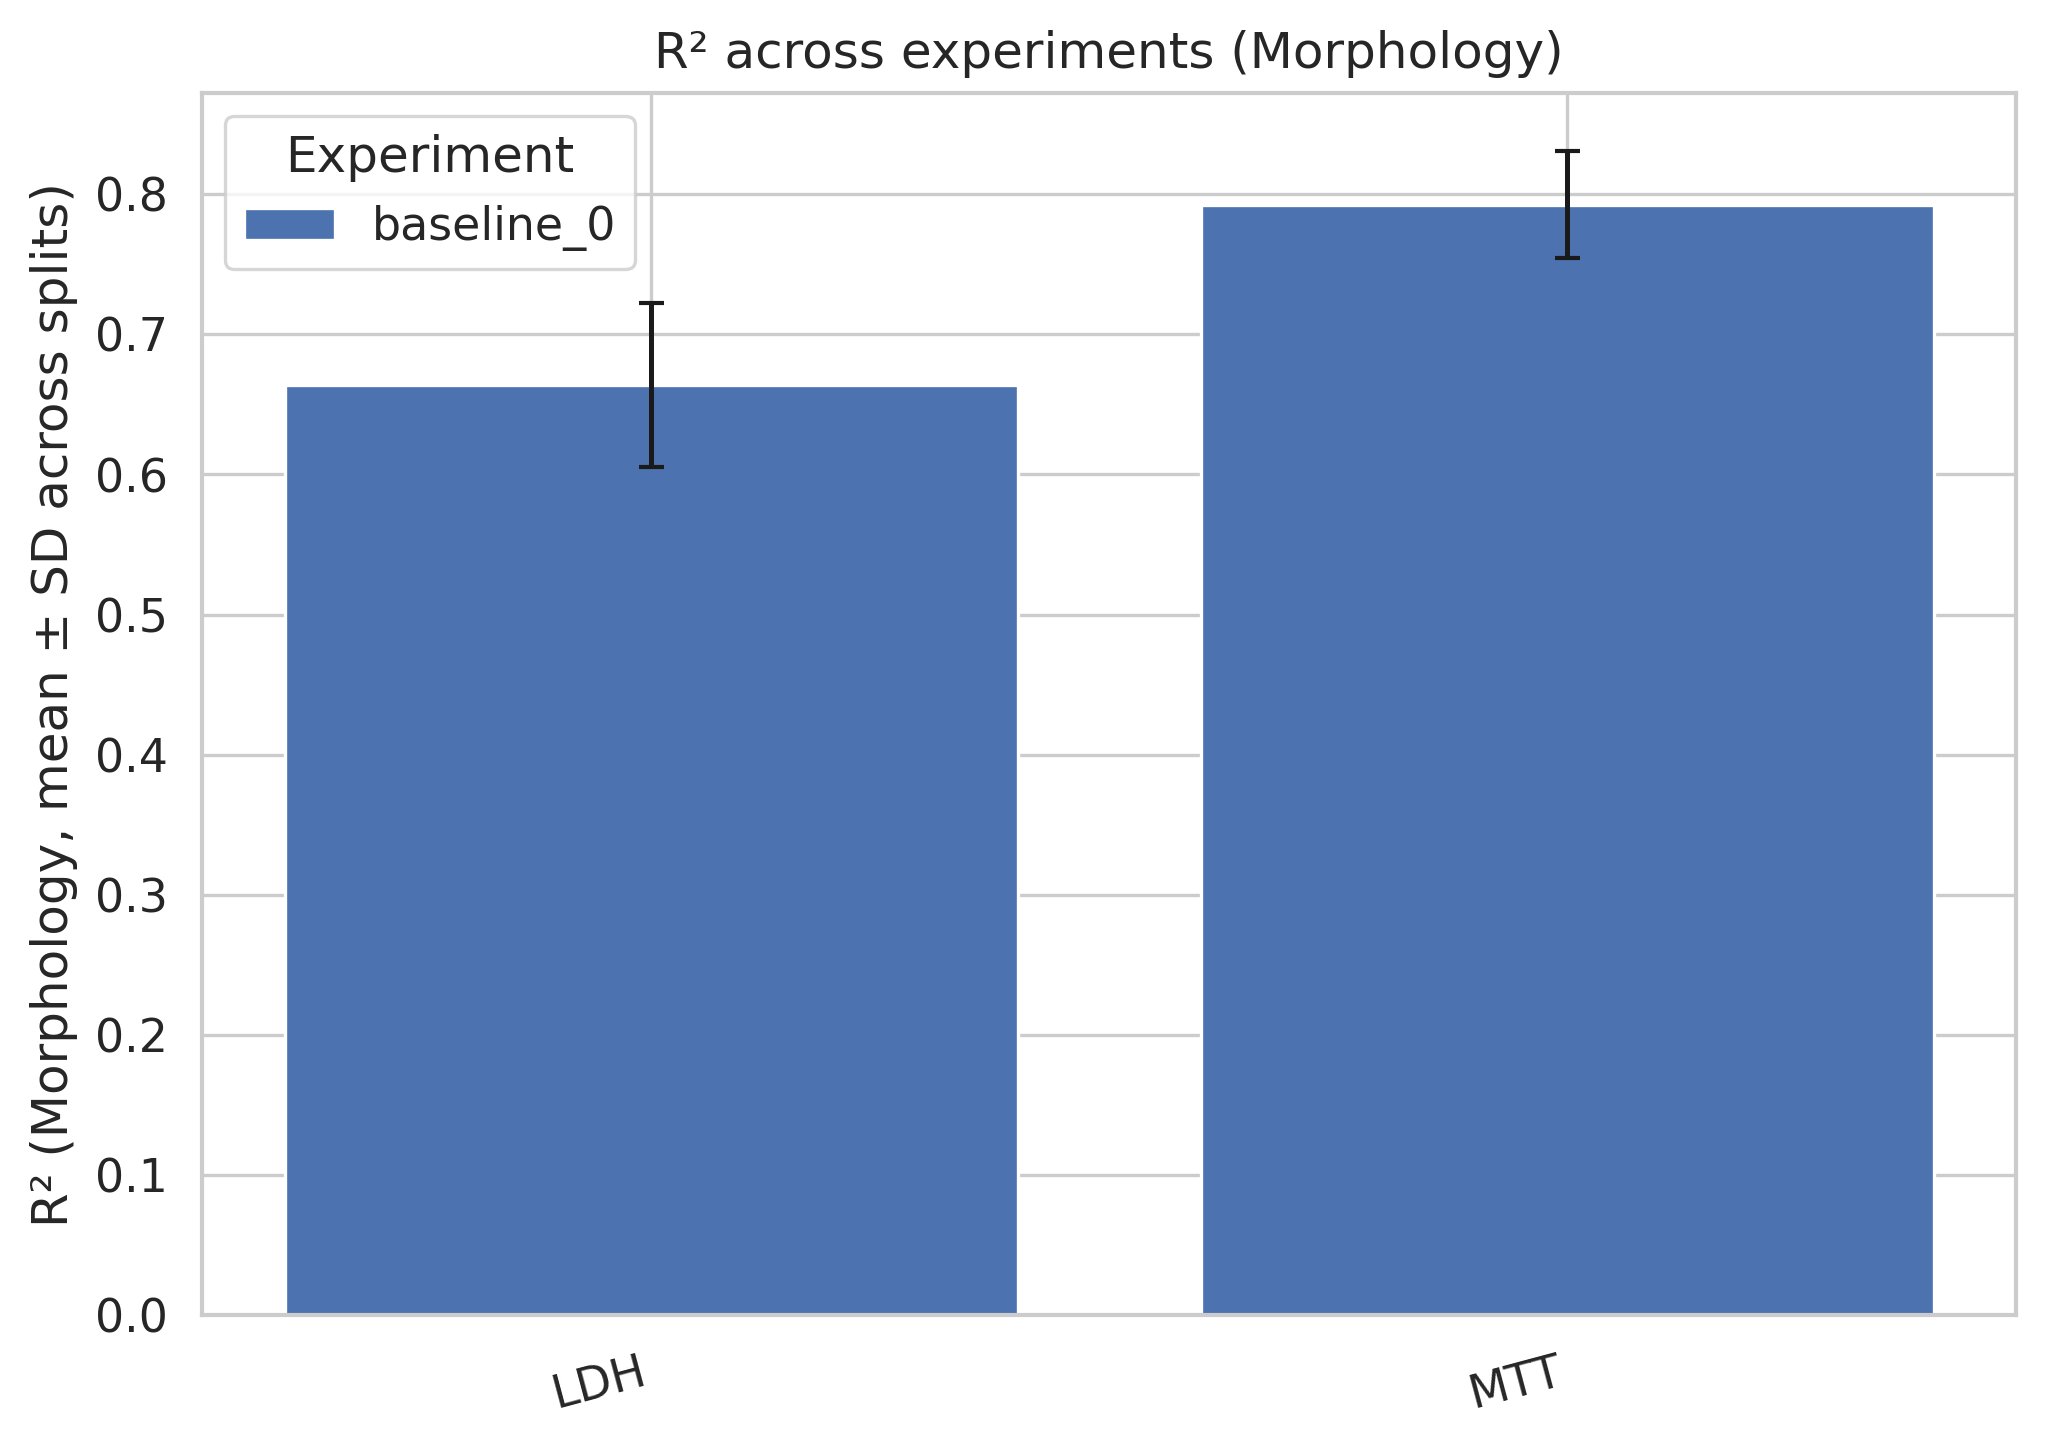

In [26]:
rm_multi = eu.load_regression_metrics(*EXPERIMENTS)
p = eu.plot_experiment_comparison_r2(rm_multi, FIG / "compare_r2", "R² across experiments (Morphology)")
eu.show(p)


### UMAP embedding of the CP-CNN profile

Reuses the pipeline's own `visualize.umaps.make_umaps` (mirrors rule `make_umaps` in `rules/visualize.smk`) unmodified. Colors wells by source and cell count across all wells, then re-embeds just the bioactive wells, then just the bioactive-and-non-cytotoxic wells. This one is the slowest cell in the notebook (UMAP fit on ~21k wells, done 3 times) — expect a few minutes.

In [27]:
import visualize as vs

umap_path = OUT / "figures/umaps.pdf"
ensure(
    umap_path,
    vs.umaps.make_umaps,
    str(mad_featselect_path), str(pods_path), str(ccpods_path), str(ldhpods_path), str(mttpods_path), str(umap_path),
)
print(f"UMAP figure (multi-page PDF, not previewable inline): {umap_path}")


[skip] outputs/cpcnn/mad_featselect/figures/umaps.pdf
UMAP figure (multi-page PDF, not previewable inline): /scratch/mb03653/Dissertation/2024_09_09_Axiom_OASIS/1_snakemake/outputs/cpcnn/mad_featselect/figures/umaps.pdf


## Summary

`Baseline 0` reference artifacts for CP-CNN, saved under `3_experiments/outputs/baseline_0/`:
- `metrics/baseline_0_classifier_metrics.parquet` — AUROC/PRAUC for ToxCast (cell-based/cell-free/cytotox) and Axiom hitcalls, for `Actual` vs `Random_baseline` vs `Cellcount_baseline`, across all 3 aggregation strategies (`all`/`allpod`/`allpodcc`).
- `metrics/baseline_0_regression_metrics.parquet` — R²/RMSE/MAE for MTT & LDH continuous prediction, for `Morphology` vs `Baseline` (technical) vs `Mean_predictor`.
- `figures/*.{png,pdf}` — dissertation-ready figures (classifier AUROC, ROC curves, regression predicted-vs-observed, POD distributions, cross-experiment comparison bars, UMAP).

Every future experiment notebook (`3_experiments/b1_*.ipynb`, etc.) should reuse the same `ensure()` / `process_metrics()` pattern and write its own `metrics/<experiment>_*.parquet` into `3_experiments/outputs/<experiment>/`, so results stay directly comparable to this baseline.

In [28]:
print("=== Classifier: Actual vs baselines (mean AUROC across labels) ===")
print(
    classifier_metrics.group_by(["Outcome_type", "Model_type"])
    .agg(pl.col("AUROC").mean().round(3).alias("mean_AUROC"), pl.col("AUROC").count().alias("n_labels"))
    .sort(["Outcome_type", "Model_type"])
)

print()
print("=== Regression: Morphology vs baselines ===")
print(regression_summary)


=== Classifier: Actual vs baselines (mean AUROC across labels) ===
shape: (12, 4)
┌───────────────────┬────────────────────┬────────────┬──────────┐
│ Outcome_type      ┆ Model_type         ┆ mean_AUROC ┆ n_labels │
│ ---               ┆ ---                ┆ ---        ┆ ---      │
│ str               ┆ str                ┆ f64        ┆ u32      │
╞═══════════════════╪════════════════════╪════════════╪══════════╡
│ axiom             ┆ Actual             ┆ 0.889      ┆ 9        │
│ axiom             ┆ Cellcount_baseline ┆ 0.798      ┆ 9        │
│ axiom             ┆ Random_baseline    ┆ 0.491      ┆ 9        │
│ toxcast_cellbased ┆ Actual             ┆ 0.602      ┆ 801      │
│ …                 ┆ …                  ┆ …          ┆ …        │
│ toxcast_cellfree  ┆ Random_baseline    ┆ 0.488      ┆ 159      │
│ toxcast_cytotox   ┆ Actual             ┆ 0.696      ┆ 102      │
│ toxcast_cytotox   ┆ Cellcount_baseline ┆ 0.601      ┆ 102      │
│ toxcast_cytotox   ┆ Random_baseline    ┆ 0.50